In [3]:
#import packages 

import pandas as pd
import matplotlib.pyplot as plt
import scipy as sc
import numpy as np
from scipy.stats import linregress


In [4]:
#reading files 
# all pteropods

pterodata = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Summary') 
wpterodata = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'Water Column Batch Analysis') 
wpterodatanonan = pd.read_excel('Pteropod_summary_MeCa.xlsx', sheet_name= 'water column excluding nans')
#drop Nans
pterodata = pterodata.dropna()
#wpterodata = wpterodata.dropna()
print(pterodata.columns)

Index(['Type', 'ID', 'Label', 'LDX', 'Cleaning', 'Sr/Ca [mmol/mol]',
       'Ba/Ca [umol/mol]', 'U/Ca [nmol/mol]', 'Na_Ca [mmol/mol]',
       'Mg_Ca [mmol/mol]', 'Mn_Ca [umol/mol]', 'Fe_Ca [umol/mol]',
       'Al_Ca [umol/mol]', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27'],
      dtype='object')


In [5]:
#index Me/Ca data
# measured U nmols/Ca mols from water column pteropods
Sr_Ca = wpterodata['Sr/Ca [mmol/mol]']
Ba_Ca = wpterodata['Ba/Ca [umol/mol]']
U_Ca = wpterodata['U/Ca [nmol/mol]']
Na_Ca = wpterodata['Na_Ca [mmol/mol]']
Mg_Ca = wpterodata['Mg_Ca [mmol/mol]']
Mn_Ca = wpterodata['Mn_Ca [umol/mol]']
Fe_Ca = wpterodata['Fe_Ca [umol/mol]']
Al_Ca = wpterodata['Al_Ca [umol/mol]']

#drop nan values
Na_Ca = Na_Ca.dropna().values.flatten()
Mg_Ca = Mg_Ca.dropna().values.flatten()
Mn_Ca = Mn_Ca.dropna().values.flatten()
Fe_Ca = Fe_Ca.dropna().values.flatten()
Al_Ca = Al_Ca.dropna().values.flatten()


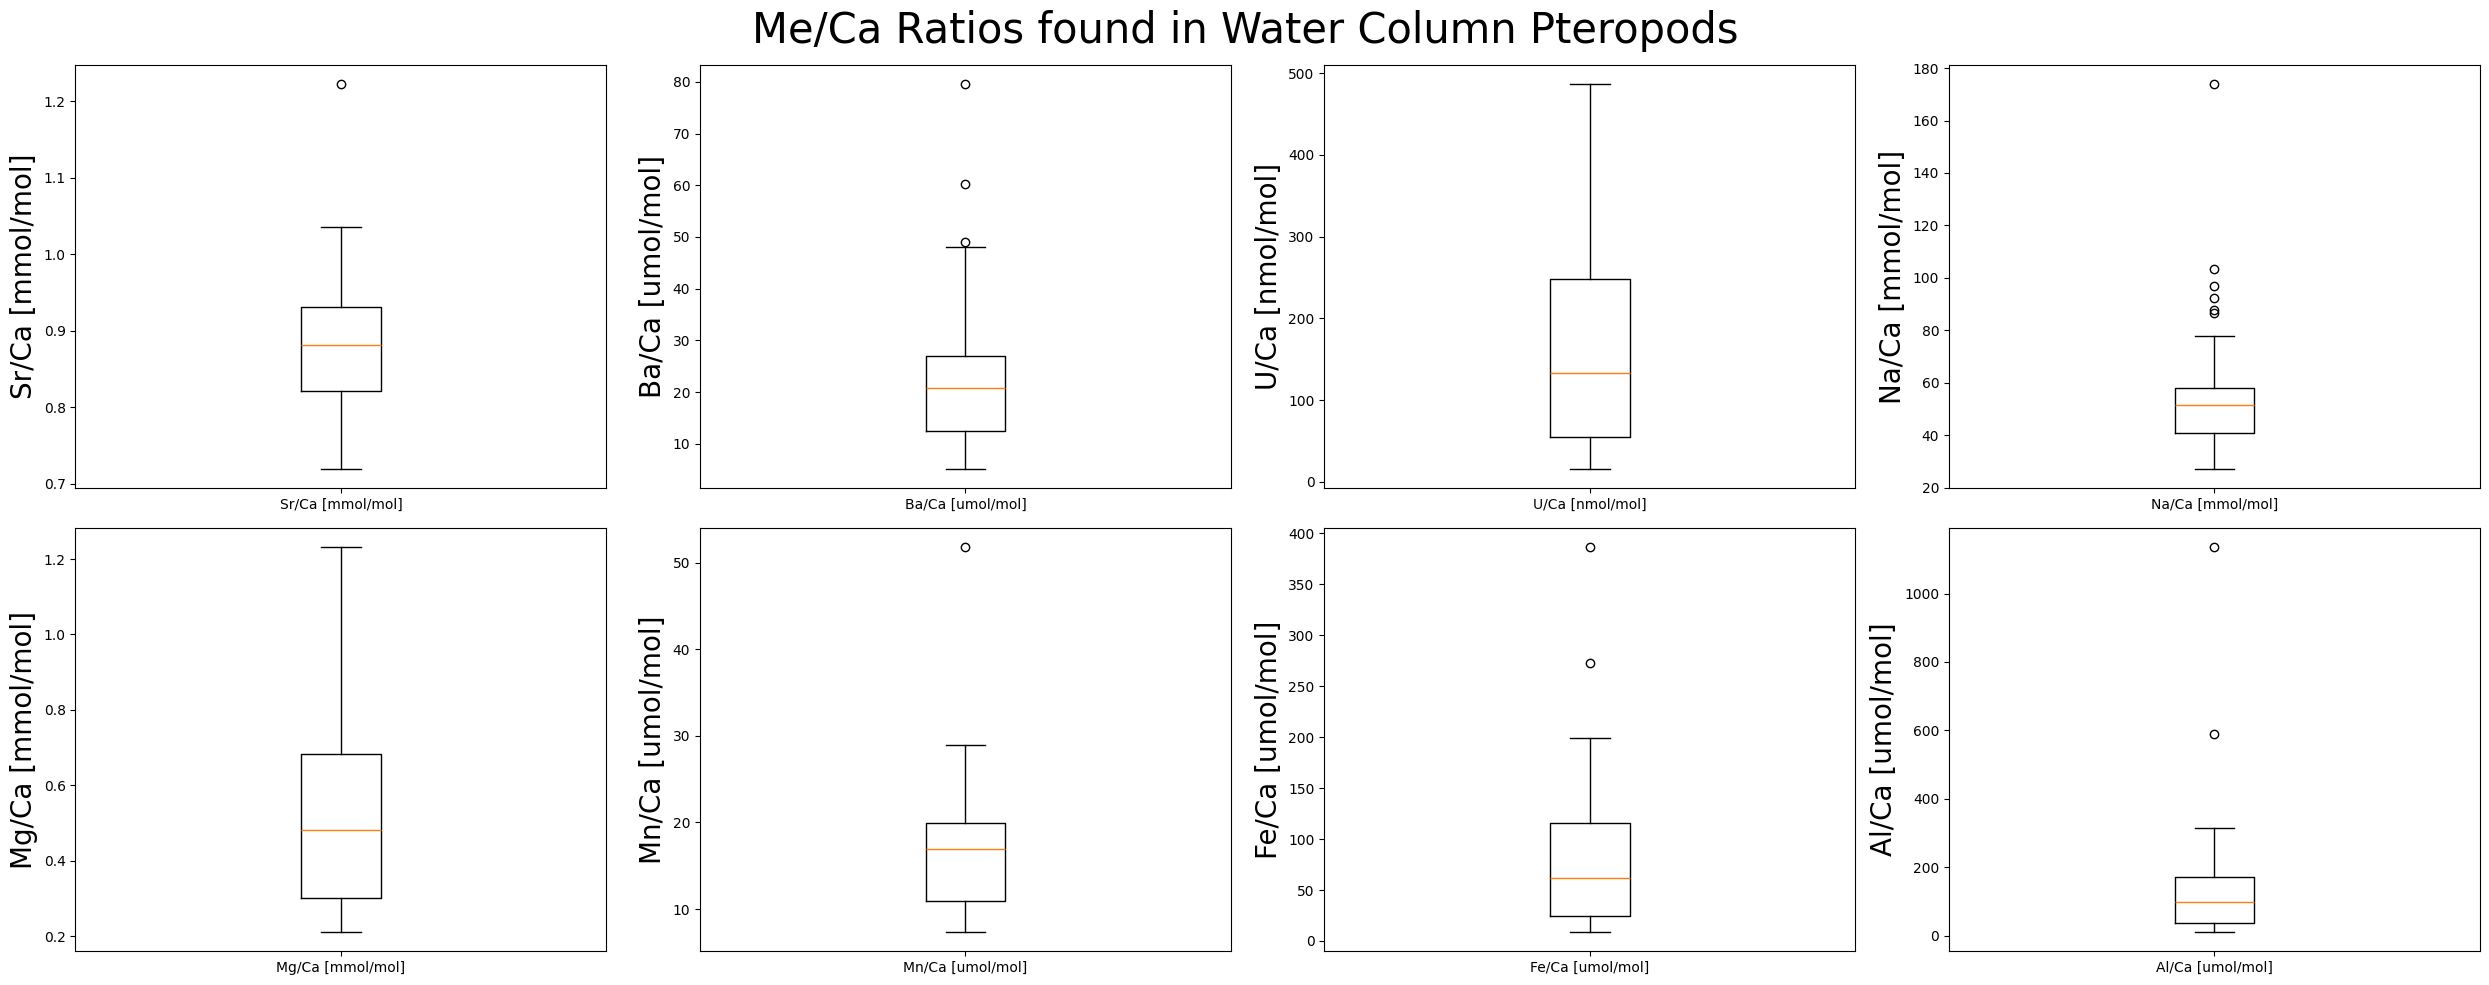

In [6]:
#Graph 1: water column pteropods vs Me/Ca ratios 

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Sr_Ca}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Ba_Ca}
U_Caname = {'U/Ca [nmol/mol]' : U_Ca}
Na_Caname = {'Na/Ca [mmol/mol]': Na_Ca}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mg_Ca} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mn_Ca}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fe_Ca}
Al_Caname =  {'Al/Ca [umol/mol]' : Al_Ca}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


#create boxplots

# add this code to make boxplots colorful
# , patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='darkblue'),
#             medianprops=dict(color='red'),
#             whiskerprops=dict(color='b'))

ax1.boxplot(Sr_Ca, tick_labels=Sr_Caname)

ax2.boxplot(Ba_Ca, tick_labels=Ba_Caname)

ax3.boxplot(U_Ca, tick_labels=U_Caname)

ax4.boxplot(Na_Ca, tick_labels=Na_Caname)

ax5.boxplot(Mg_Ca, tick_labels=Mg_Caname)

ax6.boxplot(Mn_Ca, tick_labels=Mn_Caname)

ax7.boxplot(Fe_Ca, tick_labels=Fe_Caname) 

ax8.boxplot(Al_Ca, tick_labels=Al_Caname)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods', fontsize = 30)
# fig.supxlabel('Me/Ca Ratio', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



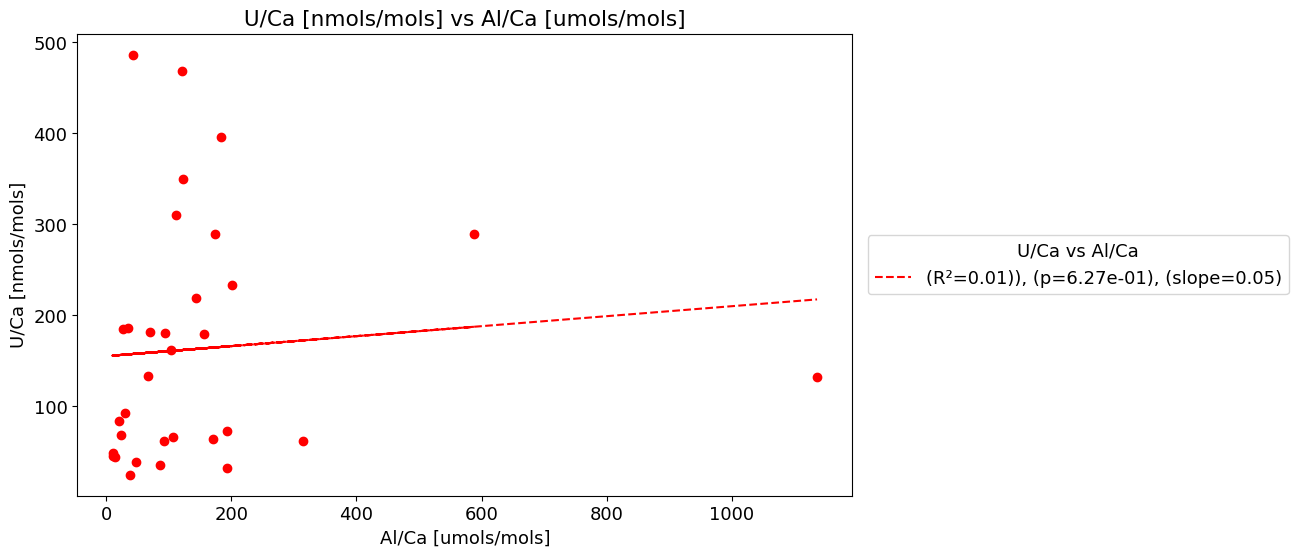

In [7]:
#graph 2: U/Ca vs Al/Ca linear regression for water column pteropods

U_Ca2 = wpterodatanonan['U/Ca [nmol/mol]']

# calulate linear regression
slopeUAl, interceptUAl, r_valueUAl, p_valueUAl, std_errUAl = linregress(Al_Ca, U_Ca2)
regression_yUAl = slopeUAl * Al_Ca + interceptUAl
r_squaredUAl = r_valueUAl**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(Al_Ca, U_Ca2, color = 'r')

#plot linear regression
plt.plot(Al_Ca, regression_yUAl, label=f'(R²={r_squaredUAl:.2f})), (p={p_valueUAl:.2e}), (slope={slopeUAl:.2f})', color='r', linestyle='--')

# axis labels 
plt.ylabel('U/Ca [nmols/mols]')
plt.xlabel('Al/Ca [umols/mols]')

#plot title
plt.title(' U/Ca [nmols/mols] vs Al/Ca [umols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='U/Ca vs Al/Ca', borderaxespad=0)




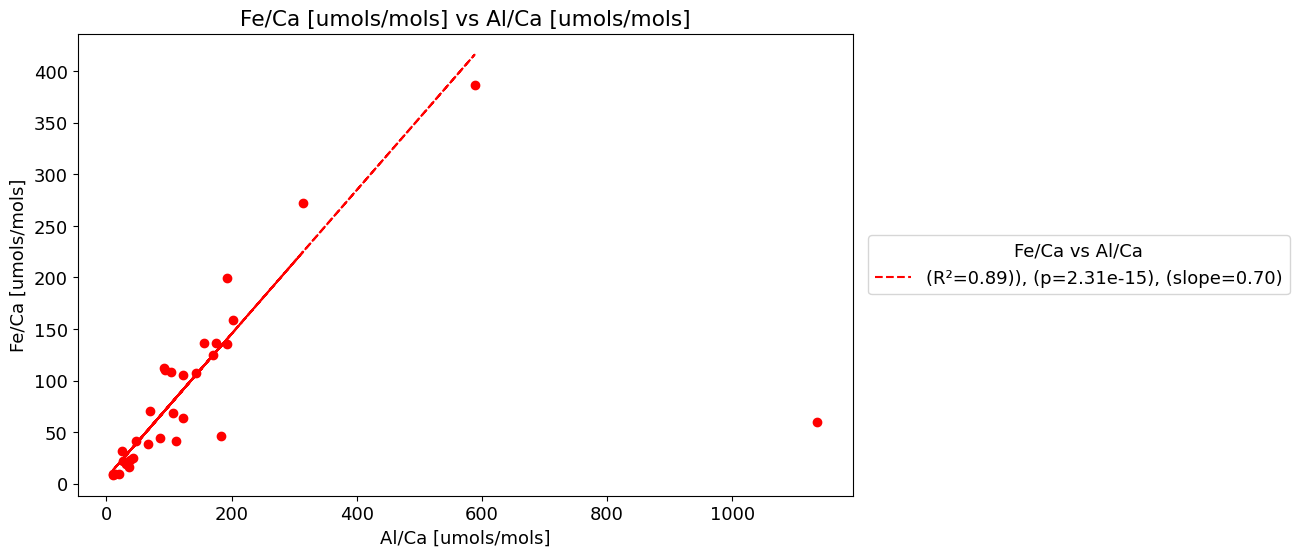

In [8]:
#graph 3: Fe/Ca vs Al/Ca linear regression for water column pteropods

#remove outliers:
Al_Ca4 = Al_Ca[0:31]
Fe_Ca4 = Fe_Ca[0:31]
# calulate linear regression
slopeFeAl, interceptFeAl, r_valueFeAl, p_valueFeAl, std_errFeAl = linregress(Al_Ca4, Fe_Ca4)
regression_yFeAl = slopeFeAl * Al_Ca4 + interceptFeAl
r_squaredFeAl = r_valueFeAl**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(Al_Ca, Fe_Ca, color = 'r')

#plot linear regression
plt.plot(Al_Ca4, regression_yFeAl, label=f'(R²={r_squaredFeAl:.2f})), (p={p_valueFeAl:.2e}), (slope={slopeFeAl:.2f})', color='r', linestyle='--')

# axis labels 
plt.ylabel('Fe/Ca [umols/mols]')
plt.xlabel('Al/Ca [umols/mols]')

#plot title
plt.title(' Fe/Ca [umols/mols] vs Al/Ca [umols/mols] ')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='Fe/Ca vs Al/Ca', borderaxespad=0)




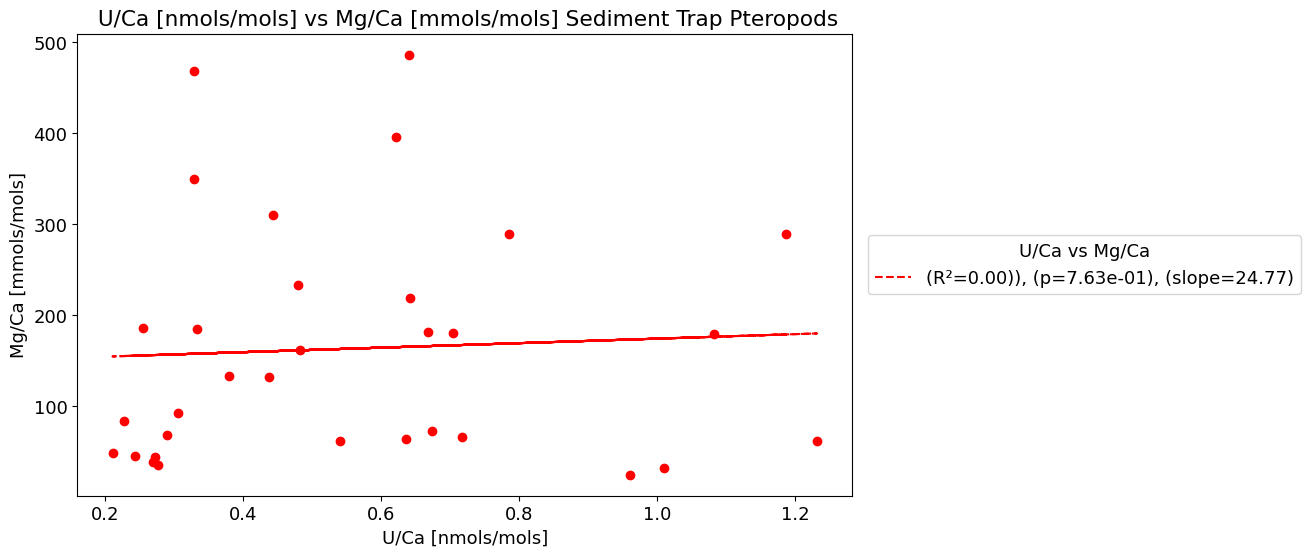

In [9]:
#graph 4: U/Ca vs Mg/Ca linear regression for water column pteropods


# calulate linear regression
slopeUMg, interceptUMg, r_valueUMg, p_valueUMg, std_errUMg = linregress(Mg_Ca, U_Ca2)
regression_yUMg = slopeUMg * Mg_Ca + interceptUMg
r_squaredUMg = r_valueUMg**2

#create figure
plt.figure(figsize=(10, 6))

#standardize font
plt.rcParams.update({'font.size': 13})

#scatter plot data
plt.scatter(Mg_Ca, U_Ca2, color = 'r')

#plot linear regression
plt.plot(Mg_Ca, regression_yUMg, label=f'(R²={r_squaredUMg:.2f})), (p={p_valueUMg:.2e}), (slope={slopeUMg:.2f})', color='r', linestyle='--')

# axis labels 
plt.ylabel('Mg/Ca [mmols/mols]')
plt.xlabel('U/Ca [nmols/mols]')

#plot title
plt.title(' U/Ca [nmols/mols] vs Mg/Ca [mmols/mols] Sediment Trap Pteropods')

#create legend
plt.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', title='U/Ca vs Mg/Ca', borderaxespad=0)




In [10]:
#index data for element batch analysis

#index batches
b1 = wpterodatanonan[0:14]
b2 = wpterodatanonan[14:32]

#index Me/Ca 
b1U = b1['U/Ca [nmol/mol]']
b2U = b2['U/Ca [nmol/mol]']

b1Sr = b1['Sr/Ca [mmol/mol]']
b2Sr = b2['Sr/Ca [mmol/mol]']

b1Ba = b1['Ba/Ca [umol/mol]']
b2Ba = b2['Ba/Ca [umol/mol]']

b1Na = b1['Na_Ca [mmol/mol]']
b2Na = b2['Na_Ca [mmol/mol]']

b1Mg = b1['Mg_Ca [mmol/mol]']
b2Mg = b2['Mg_Ca [mmol/mol]']

b1Mn = b1['Mn_Ca [umol/mol]']
b2Mn = b2['Mn_Ca [umol/mol]']

b1Fe = b1['Fe_Ca [umol/mol]']
b2Fe = b2['Fe_Ca [umol/mol]']

b1Al = b1['Al_Ca [umol/mol]']
b2Al= b2['Al_Ca [umol/mol]']

#combine data for batch analysis

batchU = b1U, b2U
batchSr = b1Sr, b2Sr
batchBa = b1Ba, b2Ba
batchNa = b1Na, b2Na
batchMg = b1Mg, b2Mg
batchMn = b1Mn, b2Mn
batchFe = b1Fe, b2Fe
batchAl = b1Al, b2Al


Text(0.5, 1.0, 'U/Ca [nmol/mol] vs Element Batch Number')

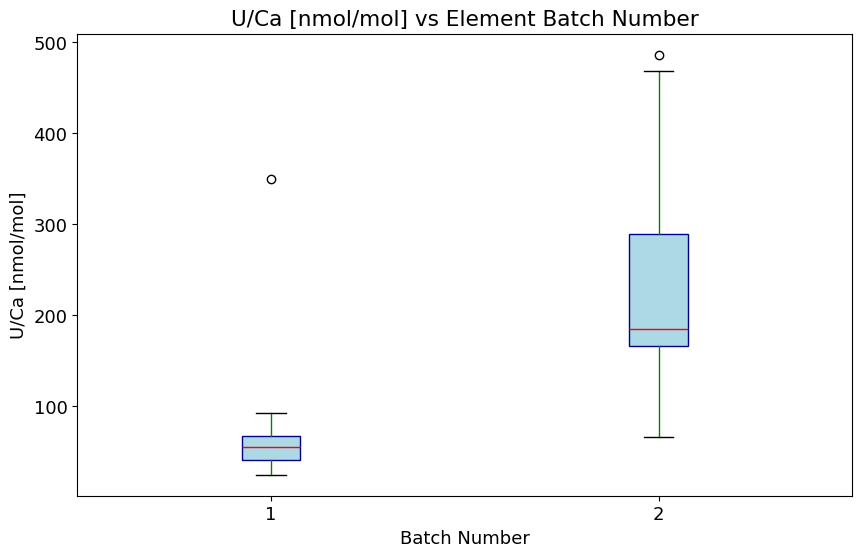

In [11]:
#graph 5 U/Ca water column element batch analysis 

#combining data
batchU = b1U, b2U

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(batchU, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))


#label axes
plt.xlabel('Batch Number')
plt.ylabel('U/Ca [nmol/mol]')

#plot title
plt.title('U/Ca [nmol/mol] vs Element Batch Number')

#add grid lines
# plt.grid()

Text(0.5, 1.0, 'Sr/Ca [mmol/mol] vs Element Batch Number')

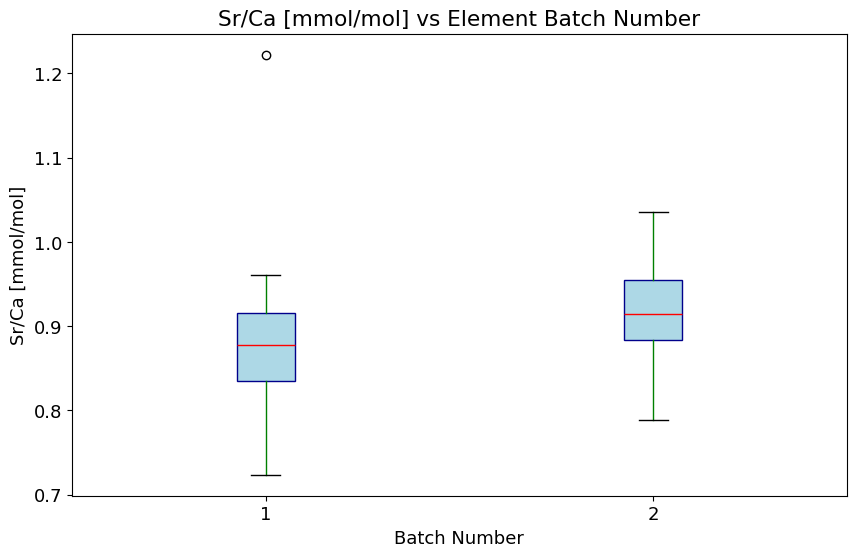

In [12]:
#graph 6 Sr/Ca water column element batch analysis 

#combining data
batchSr = b1Sr, b2Sr

#create figure
plt.figure(figsize=(10, 6))

#create boxplot
plt.boxplot(batchSr, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='darkblue'),
            medianprops=dict(color='red'),
            whiskerprops=dict(color='green'))


#label axes
plt.xlabel('Batch Number')
plt.ylabel('Sr/Ca [mmol/mol]')

#plot title
plt.title('Sr/Ca [mmol/mol] vs Element Batch Number')

#add grid lines
# plt.grid()

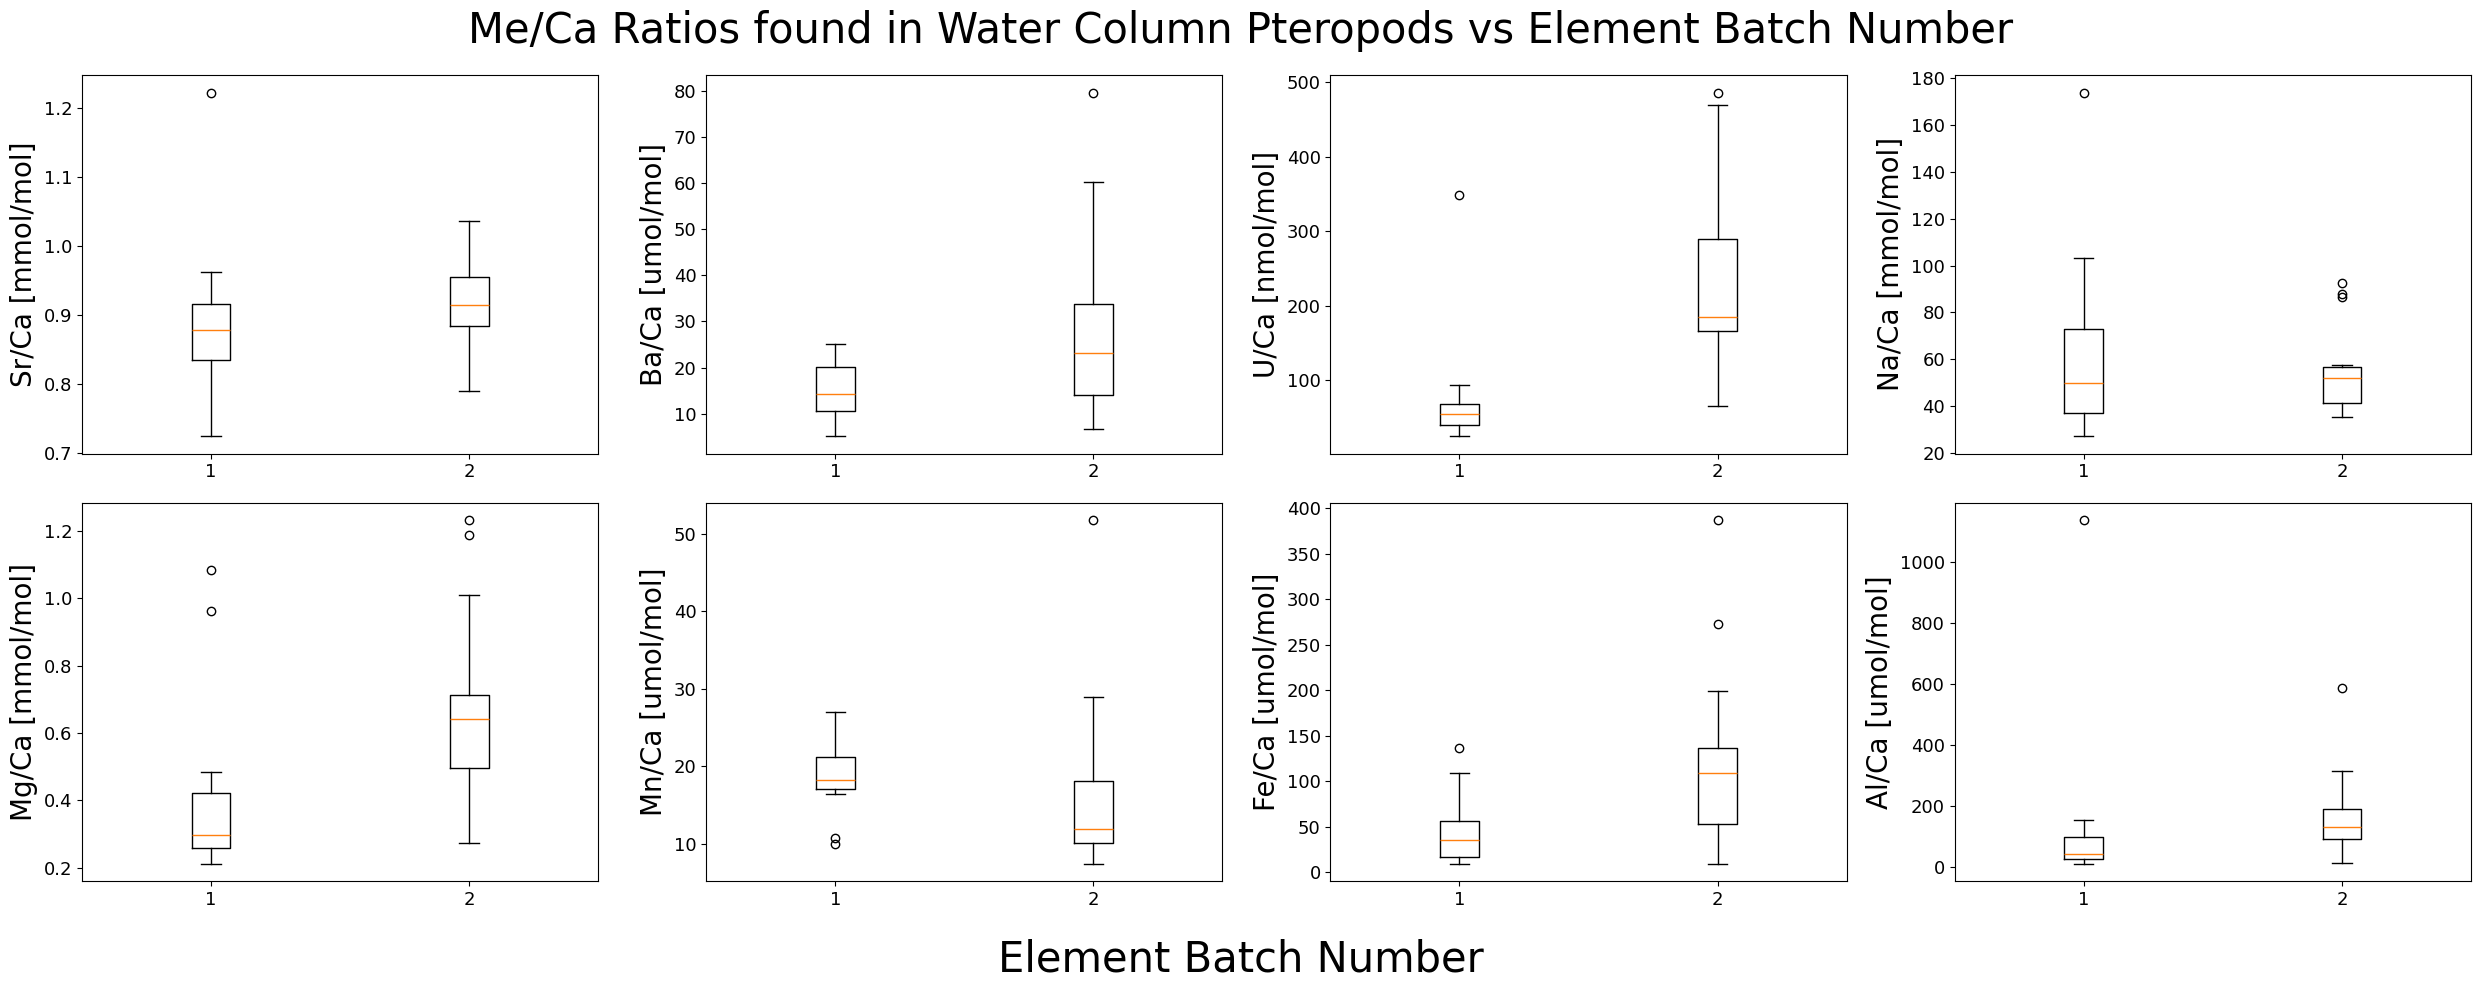

In [13]:
#Graph 7: water column pteropods batch # vs Me/Ca ratios 

#labeling boxplots
Sr_Caname= {'Sr/Ca [mmol/mol]' :Sr_Ca}
Ba_Caname = { 'Ba/Ca [umol/mol]' : Ba_Ca}
U_Caname = {'U/Ca [nmol/mol]' : U_Ca}
Na_Caname = {'Na/Ca [mmol/mol]': Na_Ca}
Mg_Caname ={'Mg/Ca [mmol/mol]' : Mg_Ca} 
Mn_Caname = { 'Mn/Ca [umol/mol]' : Mn_Ca}
Fe_Caname = {'Fe/Ca [umol/mol]' : Fe_Ca}
Al_Caname =  {'Al/Ca [umol/mol]' : Al_Ca}


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


#create boxplots

# add this code to make boxplots colorful
# , patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='darkblue'),
#             medianprops=dict(color='red'),
#             whiskerprops=dict(color='green'))


ax1.boxplot(batchSr)

ax2.boxplot(batchBa)

ax3.boxplot(batchU)

ax4.boxplot(batchNa)

ax5.boxplot(batchMg)

ax6.boxplot(batchMn)

ax7.boxplot(batchFe) 

ax8.boxplot(batchAl)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods vs Element Batch Number', fontsize = 30)
fig.supxlabel('Element Batch Number', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



In [14]:

#index data for shell vs Me/Ca analysis

shell = wpterodatanonan['Number of shells']

#index Me/Ca
Sr_Ca2 = wpterodatanonan['Sr/Ca [mmol/mol]']
Ba_Ca2 = wpterodatanonan['Ba/Ca [umol/mol]']
U_Ca2 = wpterodatanonan['U/Ca [nmol/mol]']
Na_Ca2 = wpterodatanonan['Na_Ca [mmol/mol]']
Mg_Ca2 = wpterodatanonan['Mg_Ca [mmol/mol]']
Mn_Ca2 = wpterodatanonan['Mn_Ca [umol/mol]']
Fe_Ca2 = wpterodatanonan['Fe_Ca [umol/mol]']
Al_Ca2 = wpterodatanonan['Al_Ca [umol/mol]']


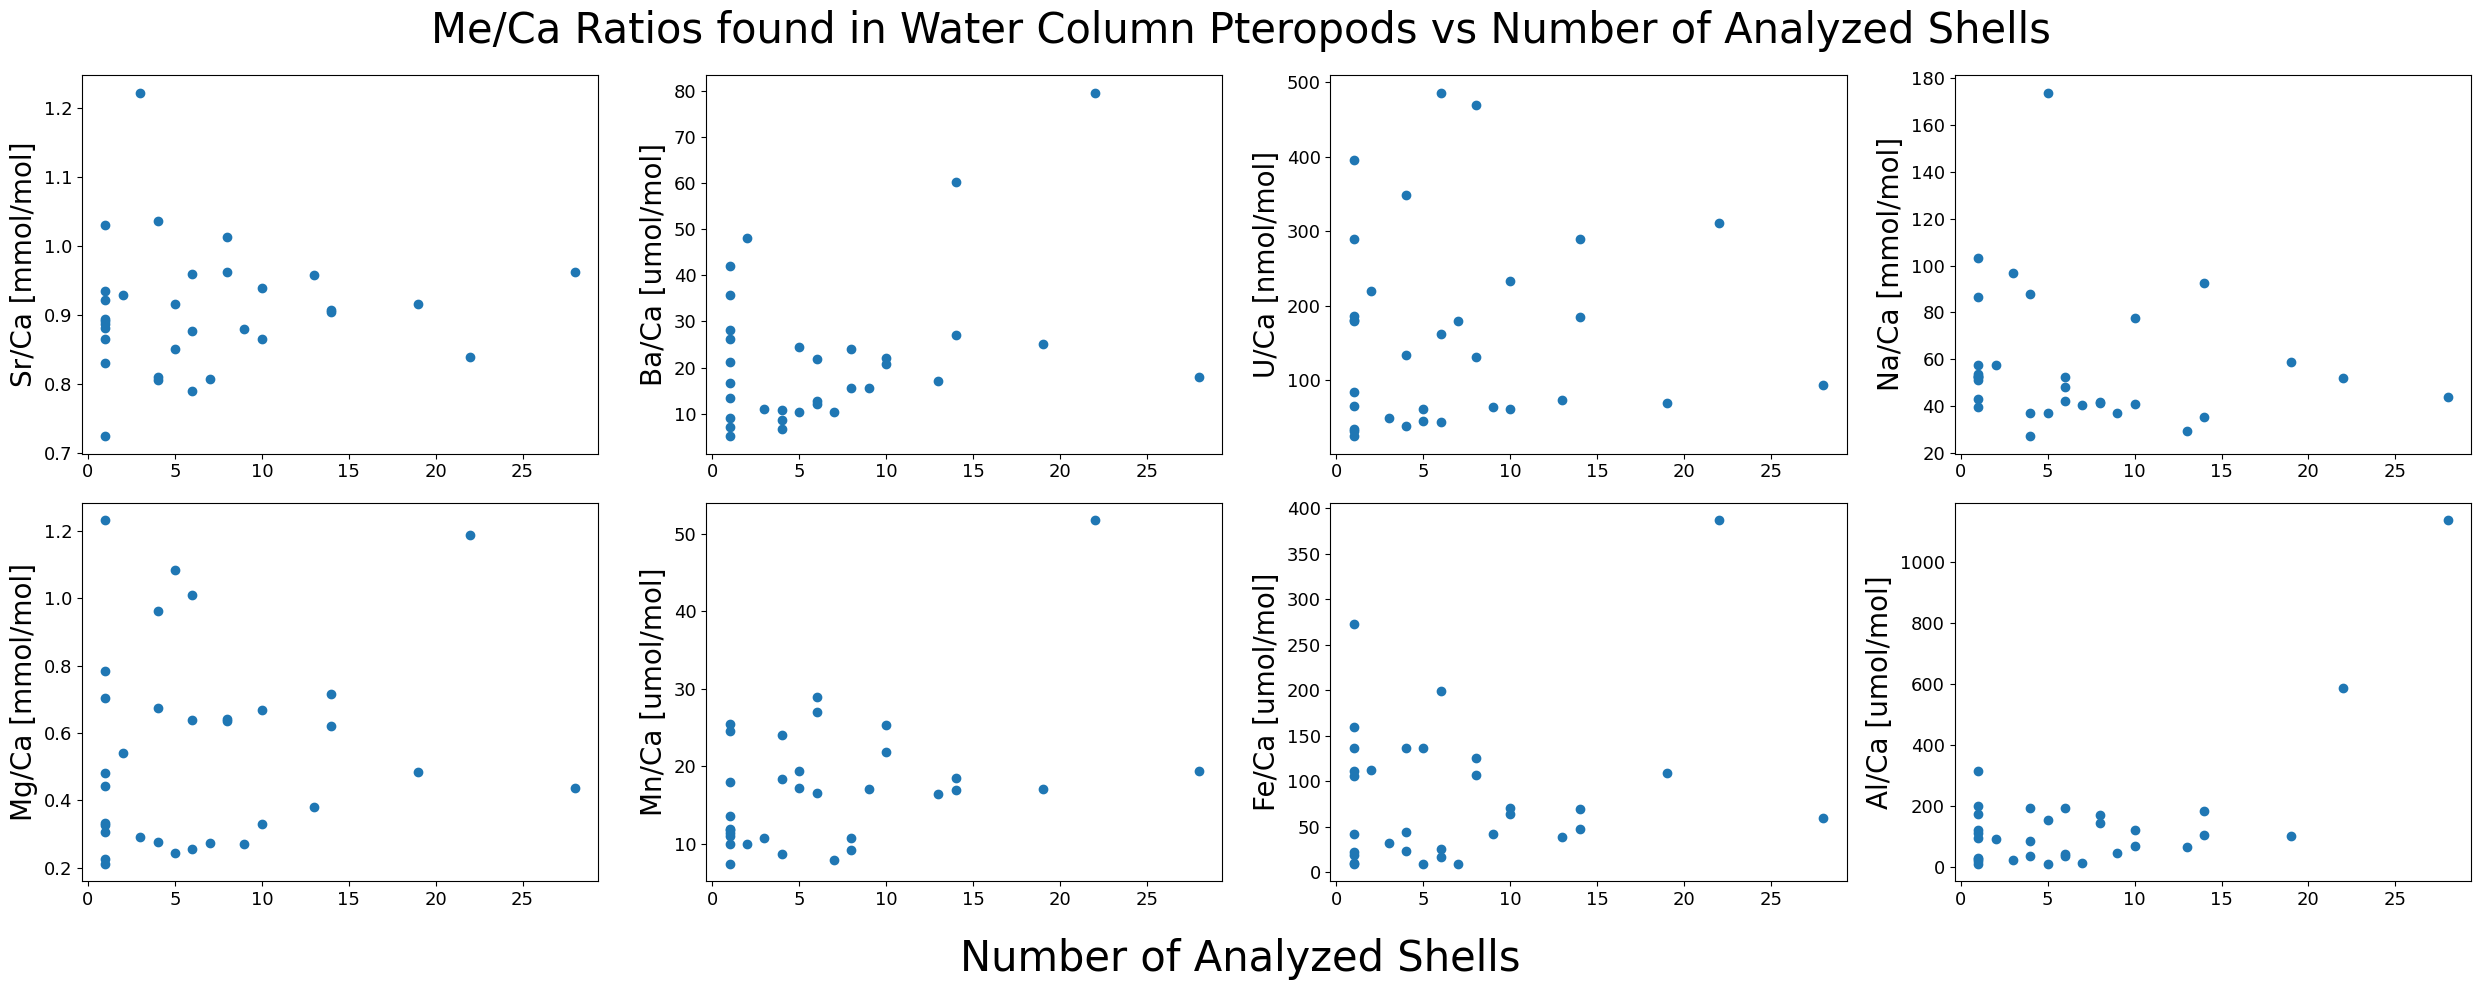

In [15]:
#Graph 8: water column pteropods number of shells vs Me/Ca 

#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#create boxplots

# add this code to make boxplots colorful
# , patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='darkblue'),
#             medianprops=dict(color='red'),
#             whiskerprops=dict(color='green'))


ax1.scatter(shell, Sr_Ca2)

ax2.scatter(shell, Ba_Ca2)

ax3.scatter(shell, U_Ca2)

ax4.scatter(shell, Na_Ca2)

ax5.scatter(shell, Mg_Ca2)

ax6.scatter(shell, Mn_Ca2)

ax7.scatter(shell, Fe_Ca2) 

ax8.scatter(shell, Al_Ca2)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods vs Number of Analyzed Shells', fontsize = 30)
fig.supxlabel('Number of Analyzed Shells', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



In [16]:
#index data for shell vs Me/Ca analysis

shell = wpterodatanonan['Number of shells']
shell2 = shell[0:25]

#index Me/Ca
Sr_Ca3 = Sr_Ca2[0:25]
Ba_Ca3 = Ba_Ca2[0:25]
U_Ca3 = U_Ca2[0:25]
Na_Ca3 = Na_Ca2[0:25]
Mg_Ca3 = Mg_Ca2[0:25]
Mn_Ca3 = Mn_Ca2[0:25]
Fe_Ca3 = Fe_Ca2[0:25]
Al_Ca3 = Fe_Ca2[0:25]

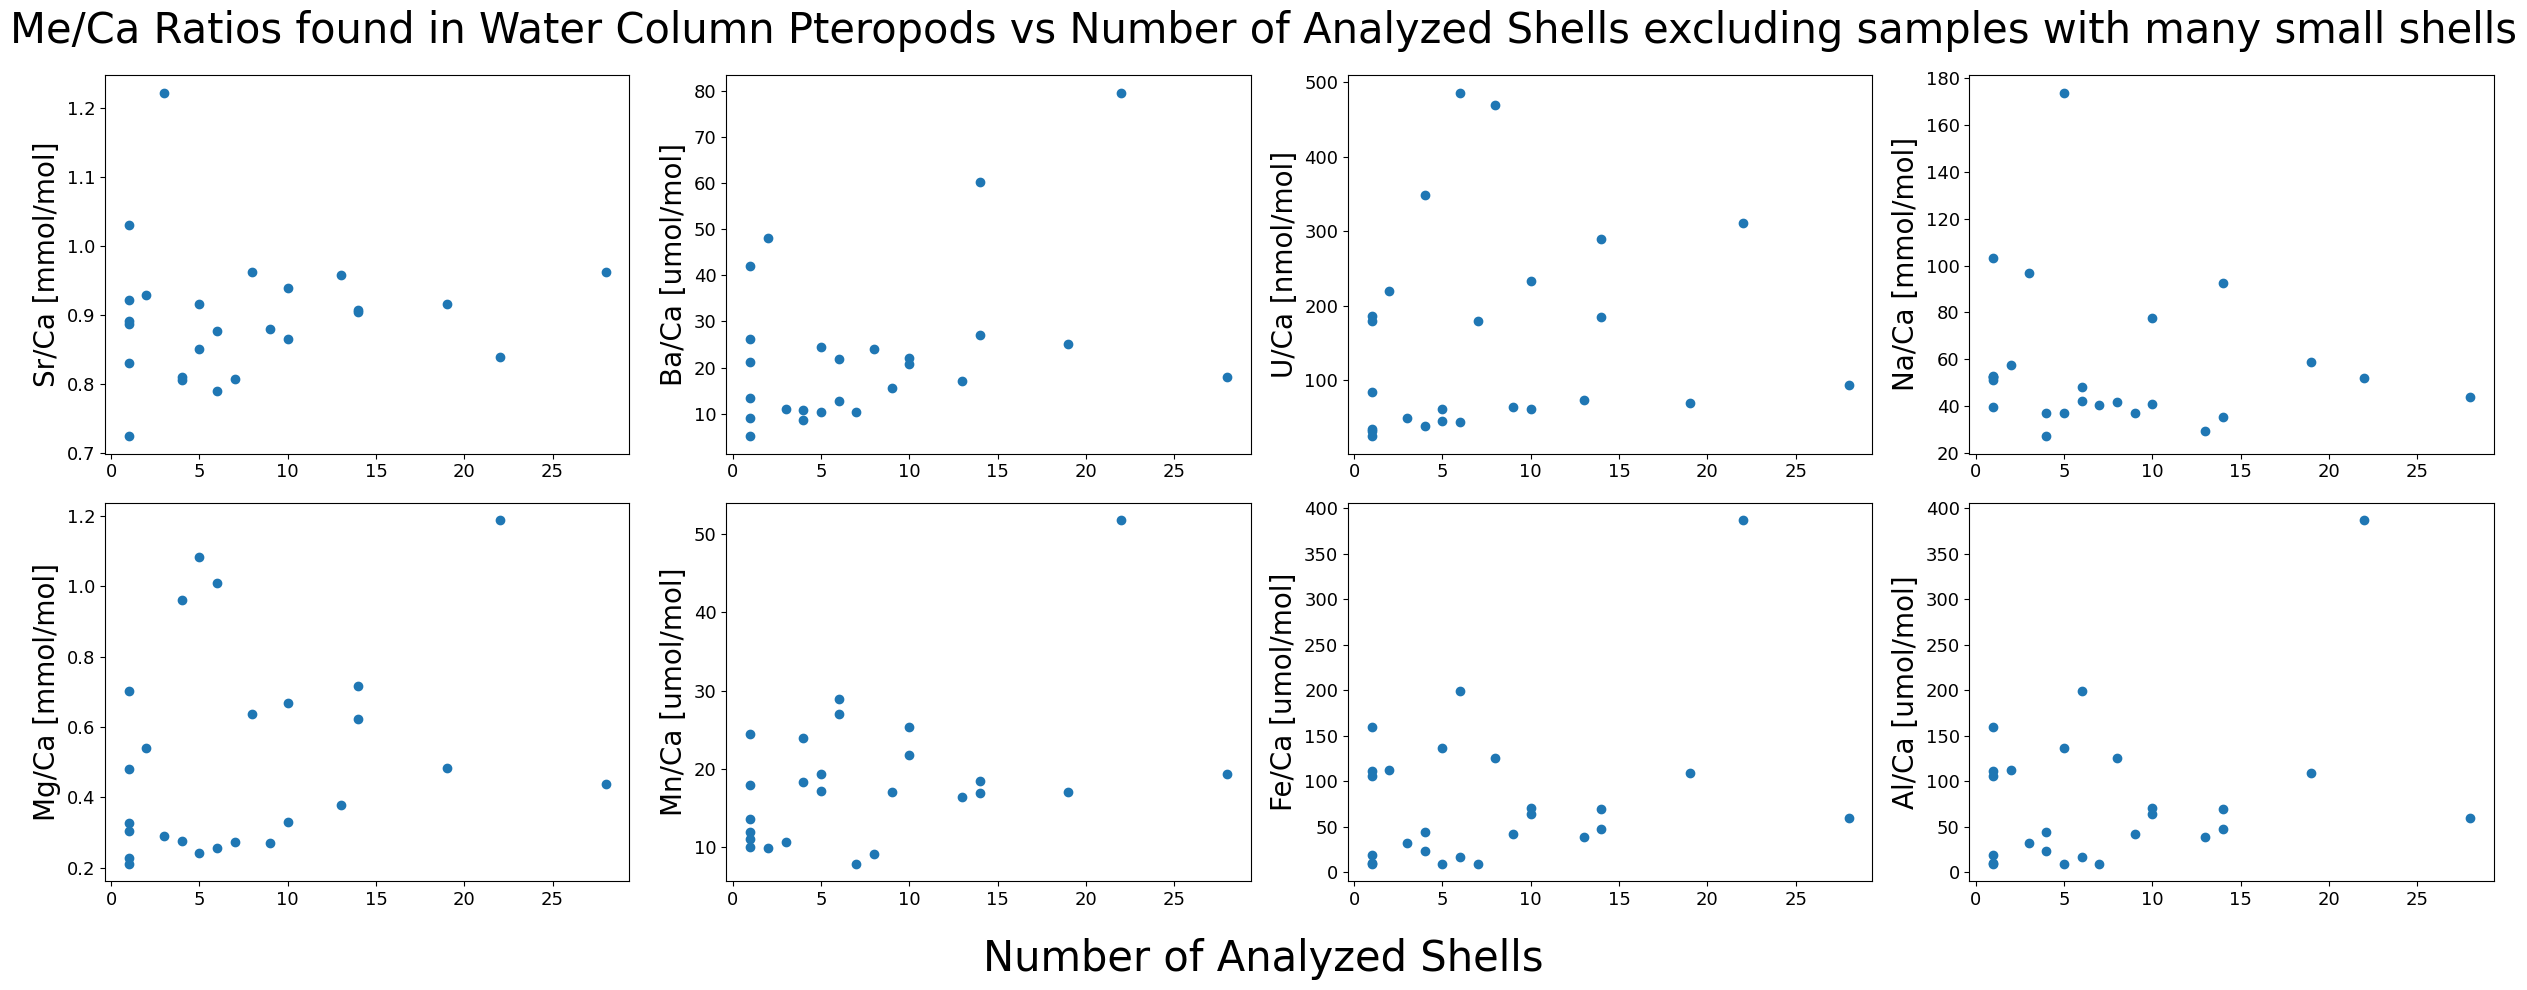

In [17]:
#Graph 8: water column pteropods number of shells vs Me/Ca excluding the last 7 that had very small shells 

#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()

#create boxplots

# add this code to make boxplots colorful
# , patch_artist=True,
#             boxprops=dict(facecolor='lightblue', color='darkblue'),
#             medianprops=dict(color='red'),
#             whiskerprops=dict(color='green'))

ax1.scatter(shell2, Sr_Ca3)

ax2.scatter(shell2, Ba_Ca3)

ax3.scatter(shell2, U_Ca3)

ax4.scatter(shell2, Na_Ca3)

ax5.scatter(shell2, Mg_Ca3)

ax6.scatter(shell2, Mn_Ca3)

ax7.scatter(shell2, Fe_Ca3) 

ax8.scatter(shell2, Al_Ca3)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')



#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods vs Number of Analyzed Shells excluding samples with many small shells', fontsize = 30)
fig.supxlabel('Number of Analyzed Shells', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#add grid lines
# ax1.grid()



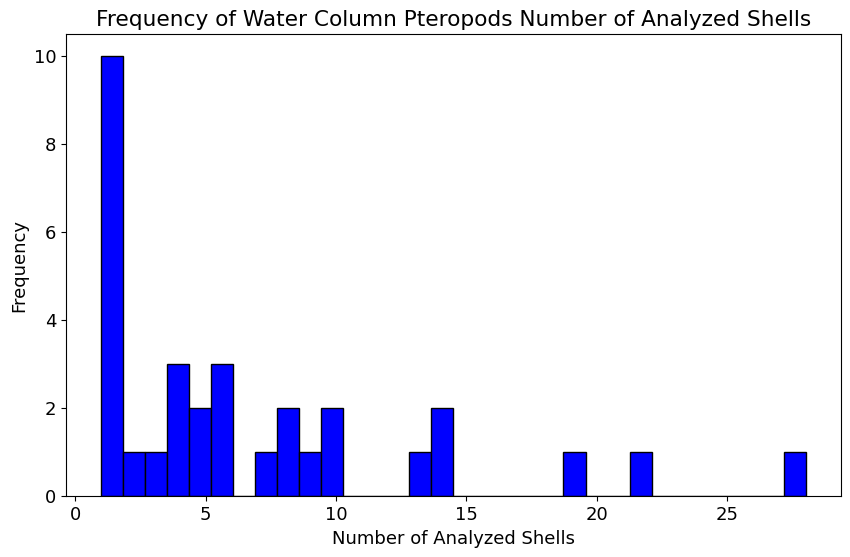

In [18]:
# graph 9: Creating histogram for shell #
#create figure
plt.subplots( figsize=(10, 6))

#plot shell data
plt.hist(shell, bins=32, color='blue', edgecolor='black')
plt.title('Frequency of Water Column Pteropods Number of Analyzed Shells')
# Adding labels and title
plt.xlabel('Number of Analyzed Shells')
plt.ylabel('Frequency')
# Display the figure
plt.show()

In [19]:
#pull out LDX variable 

LDX = wpterodata['LDX']
LDX2 = wpterodatanonan['LDX']

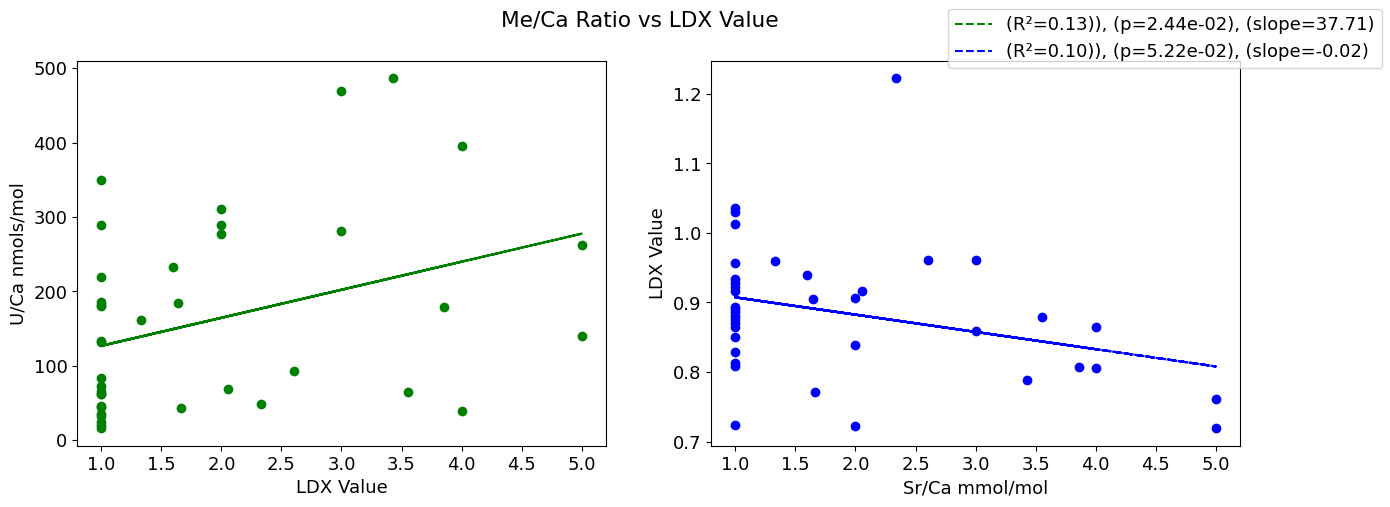

In [20]:
#graph 10 LDX values vs U/Ca vs Sr/Ca

#create figure
fig, axes = plt.subplots(1,2,figsize=(15, 5))

# calulate linear regression U/Ca 
slopeLDXU, interceptLDXU, r_valueLDXU, p_valueLDXU, std_errLDXU = linregress(LDX, U_Ca)
regression_yLDXU = slopeLDXU * LDX + interceptLDXU
r_squaredLDXU = r_valueLDXU**2

# calulate linear regression Sr/Ca
slopeLDXSr, interceptLDXSr, r_valueLDXSr, p_valueLDXSr, std_errLDXSr = linregress(LDX, Sr_Ca)
regression_yLDXSr = slopeLDXSr * LDX + interceptLDXSr
r_squaredLDXSr = r_valueLDXSr**2

#plot linear regression U/Ca
axes[0].plot(LDX, regression_yLDXU, label=f'(R²={r_squaredLDXU:.2f})), (p={p_valueLDXU:.2e}), (slope={slopeLDXU:.2f})', color='green', linestyle='--')

#plot linear regression Sr/Ca
axes[1].plot(LDX, regression_yLDXSr, label=f'(R²={r_squaredLDXSr:.2f})), (p={p_valueLDXSr:.2e}), (slope={slopeLDXSr:.2f})', color='b', linestyle='--')


#scatter data points
axes[0].scatter(LDX, U_Ca, color = 'green')
axes[1].scatter(LDX, Sr_Ca, color = 'blue')

#name axes
axes[0].set_xlabel('LDX Value')
axes[0].set_ylabel('U/Ca nmols/mol')

axes[1].set_xlabel('Sr/Ca mmol/mol')
axes[1].set_ylabel('LDX Value')

#set title
fig.suptitle('Me/Ca Ratio vs LDX Value')
fig.legend()


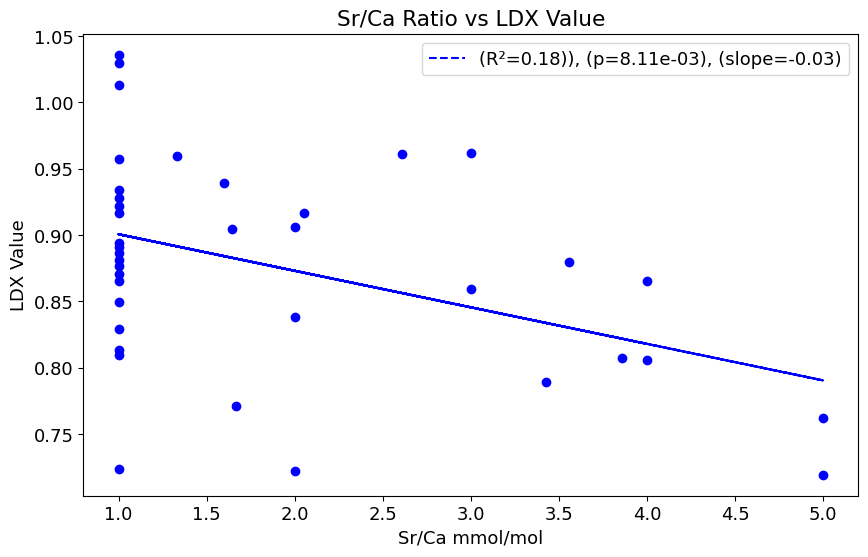

In [21]:
#graph 11 LDX vs Sr/Ca excluding one outlier

#graph 10 LDX values vs U/Ca vs Sr/Ca

out = wpterodata.drop(wpterodata.index[11])
Sr_Caout = out['Sr/Ca [mmol/mol]']
LDXout = out['LDX']


#create figure
plt.figure(figsize = (10,6))


# calulate linear regression Sr/Ca
slopeLDXSrout, interceptLDXSrout, r_valueLDXSrout, p_valueLDXSrout, std_errLDXSrout = linregress(LDXout, Sr_Caout)
regression_yLDXSrout = slopeLDXSrout * LDXout + interceptLDXSrout
r_squaredLDXSrout = r_valueLDXSrout**2

#plot linear regression Sr/Ca
plt.plot(LDXout, regression_yLDXSrout, label=f'(R²={r_squaredLDXSrout:.2f})), (p={p_valueLDXSrout:.2e}), (slope={slopeLDXSrout:.2f})', color='b', linestyle='--')


#scatter data points

plt.scatter(LDXout, Sr_Caout, color = 'blue')

#name axes
plt.xlabel('Sr/Ca mmol/mol')
plt.ylabel('LDX Value')

#set title
plt.title('Sr/Ca Ratio vs LDX Value')
plt.legend()


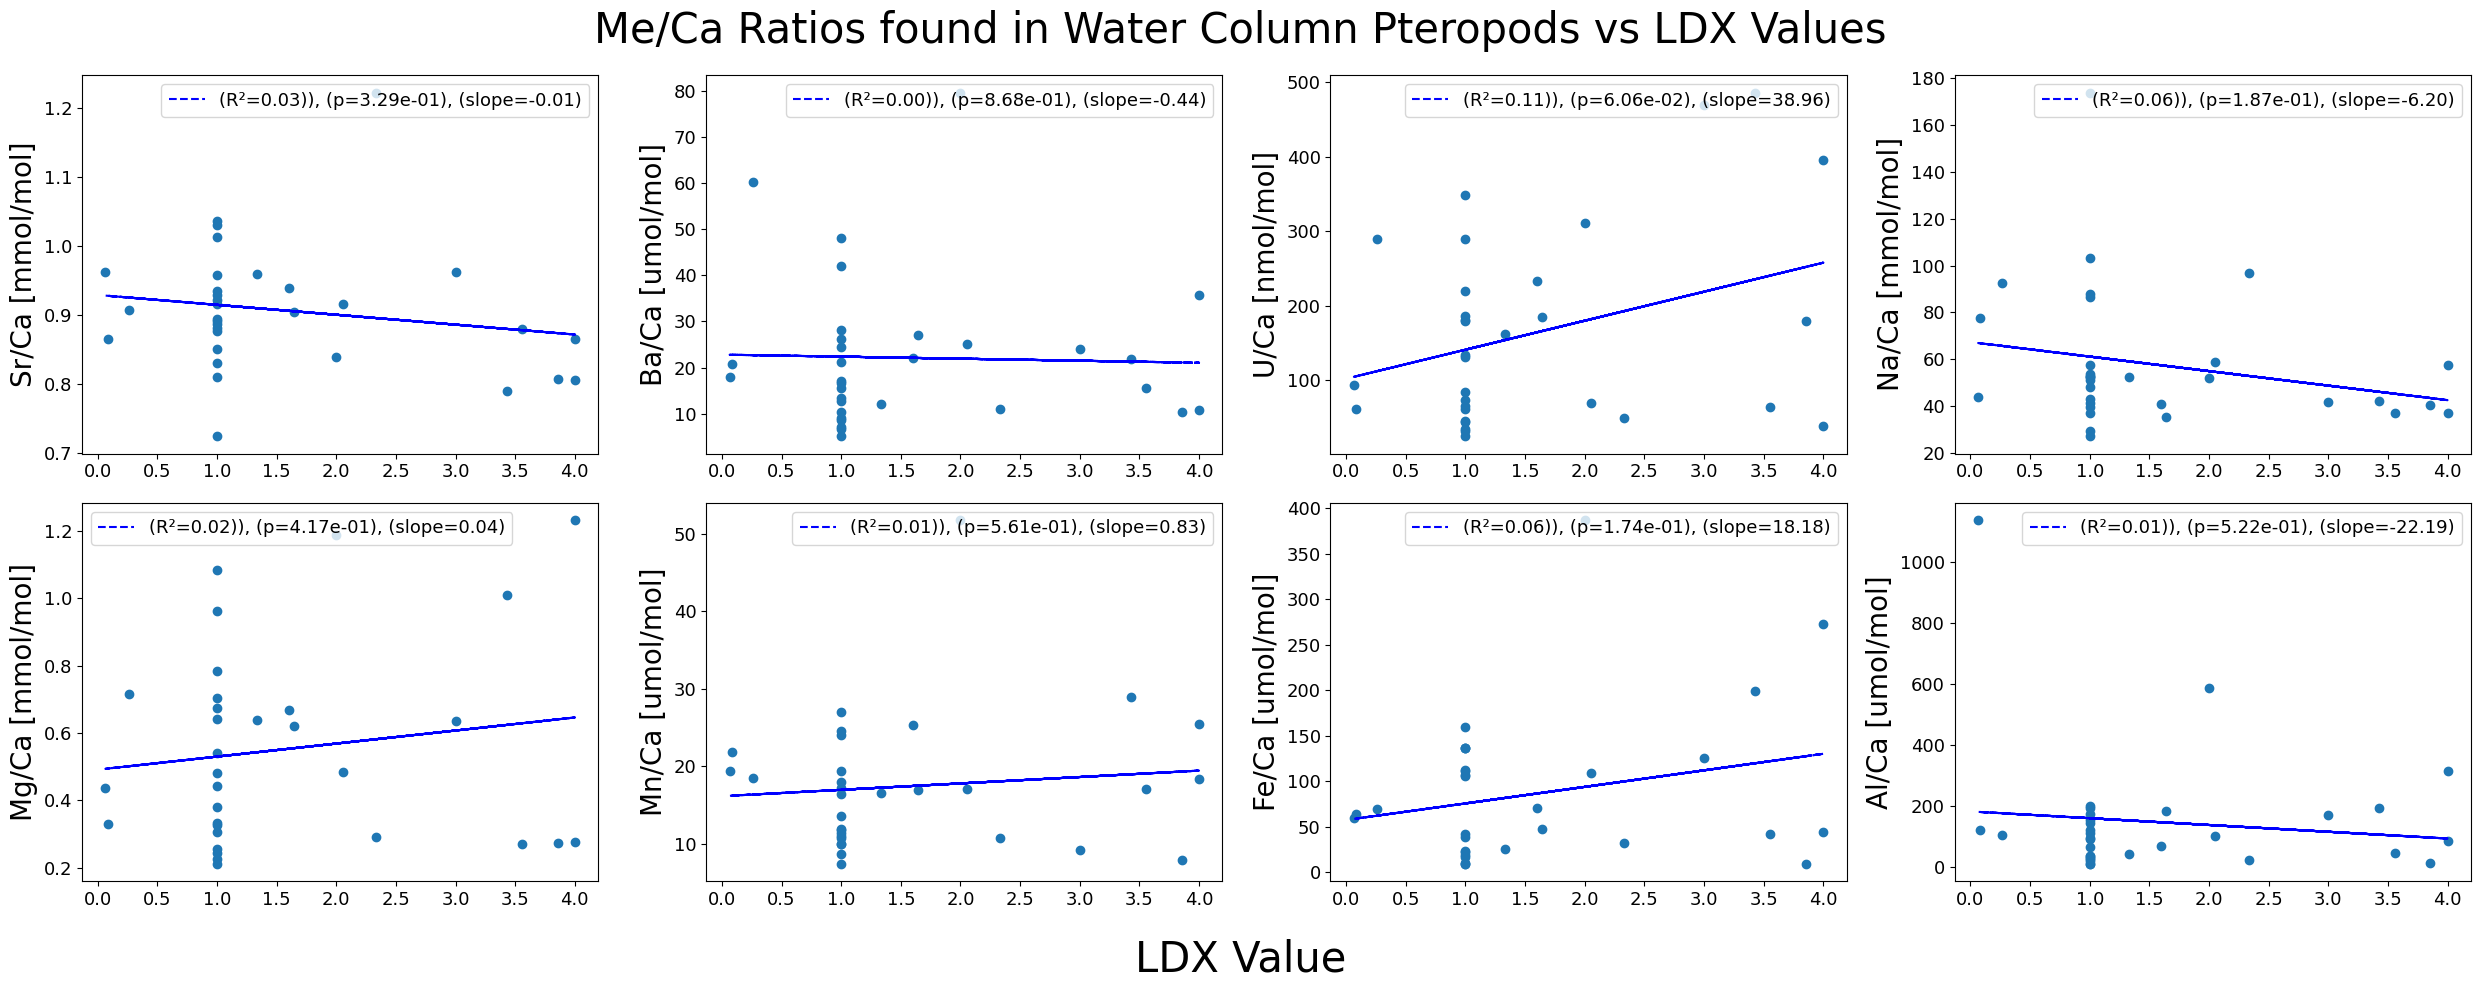

In [22]:
#graph 13: Me/Ca vs LDX


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


#create scatter plots

ax1.scatter(LDX2, Sr_Ca2)

ax2.scatter(LDX2, Ba_Ca2)

ax3.scatter(LDX2, U_Ca2)

ax4.scatter(LDX2, Na_Ca2)

ax5.scatter(LDX2, Mg_Ca2)

ax6.scatter(LDX2, Mn_Ca2)

ax7.scatter(LDX2, Fe_Ca2) 

ax8.scatter(LDX2, Al_Ca2)

# calulate linear regression 
slopeLDX2Sr, interceptLDX2Sr, r_valueLDX2Sr, p_valueLDX2Sr, std_errLDX2Sr = linregress(LDX2, Sr_Ca2)
regression_yLDX2Sr = slopeLDX2Sr * LDX2 + interceptLDX2Sr
r_squaredLDX2Sr = r_valueLDX2Sr**2

slopeLDX2Ba, interceptLDX2Ba, r_valueLDX2Ba, p_valueLDX2Ba, std_errLDX2Ba = linregress(LDX2, Ba_Ca2)
regression_yLDX2Ba = slopeLDX2Ba * LDX2 + interceptLDX2Ba
r_squaredLDX2Ba = r_valueLDX2Ba**2

slopeLDX2U, interceptLDX2U, r_valueLDX2U, p_valueLDX2U, std_errLDX2U = linregress(LDX2, U_Ca2)
regression_yLDX2U = slopeLDX2U * LDX2 + interceptLDX2U
r_squaredLDX2U = r_valueLDX2U**2

slopeLDX2Na, interceptLDX2Na, r_valueLDX2Na, p_valueLDX2Na, std_errLDX2Na = linregress(LDX2, Na_Ca2)
regression_yLDX2Na = slopeLDX2Na * LDX2 + interceptLDX2Na
r_squaredLDX2Na = r_valueLDX2Na**2

slopeLDX2Mg, interceptLDX2Mg, r_valueLDX2Mg, p_valueLDX2Mg, std_errLDX2Mg = linregress(LDX2, Mg_Ca2)
regression_yLDX2Mg = slopeLDX2Mg * LDX2 + interceptLDX2Mg
r_squaredLDX2Mg = r_valueLDX2Mg**2

slopeLDX2Mn, interceptLDX2Mn, r_valueLDX2Mn, p_valueLDX2Mn, std_errLDX2Mn = linregress(LDX2, Mn_Ca2)
regression_yLDX2Mn = slopeLDX2Mn * LDX2 + interceptLDX2Mn
r_squaredLDX2Mn = r_valueLDX2Mn**2

slopeLDX2Fe, interceptLDX2Fe, r_valueLDX2Fe, p_valueLDX2Fe, std_errLDX2Fe = linregress(LDX2, Fe_Ca2)
regression_yLDX2Fe = slopeLDX2Fe * LDX2 + interceptLDX2Fe
r_squaredLDX2Fe = r_valueLDX2Fe**2

slopeLDX2Al, interceptLDX2Al, r_valueLDX2Al, p_valueLDX2Al, std_errLDX2Al = linregress(LDX2, Al_Ca2)
regression_yLDX2Al = slopeLDX2Al * LDX2 + interceptLDX2Al
r_squaredLDX2Al = r_valueLDX2Al**2

#plot linear regression 
ax1.plot(LDX2, regression_yLDX2Sr, label=f'(R²={r_squaredLDX2Sr:.2f})), (p={p_valueLDX2Sr:.2e}), (slope={slopeLDX2Sr:.2f})', color='b', linestyle='--')

ax2.plot(LDX2, regression_yLDX2Ba, label=f'(R²={r_squaredLDX2Ba:.2f})), (p={p_valueLDX2Ba:.2e}), (slope={slopeLDX2Ba:.2f})', color='b', linestyle='--')

ax3.plot(LDX2, regression_yLDX2U, label=f'(R²={r_squaredLDX2U:.2f})), (p={p_valueLDX2U:.2e}), (slope={slopeLDX2U:.2f})', color='b', linestyle='--')

ax4.plot(LDX2, regression_yLDX2Na, label=f'(R²={r_squaredLDX2Na:.2f})), (p={p_valueLDX2Na:.2e}), (slope={slopeLDX2Na:.2f})', color='b', linestyle='--')

ax5.plot(LDX2, regression_yLDX2Mg, label=f'(R²={r_squaredLDX2Mg:.2f})), (p={p_valueLDX2Mg:.2e}), (slope={slopeLDX2Mg:.2f})', color='b', linestyle='--')

ax6.plot(LDX2, regression_yLDX2Mn, label=f'(R²={r_squaredLDX2Mn:.2f})), (p={p_valueLDX2Mn:.2e}), (slope={slopeLDX2Mn:.2f})', color='b', linestyle='--')

ax7.plot(LDX2, regression_yLDX2Fe, label=f'(R²={r_squaredLDX2Fe:.2f})), (p={p_valueLDX2Fe:.2e}), (slope={slopeLDX2Fe:.2f})', color='b', linestyle='--')

ax8.plot(LDX2, regression_yLDX2Al, label=f'(R²={r_squaredLDX2Al:.2f})), (p={p_valueLDX2Al:.2e}), (slope={slopeLDX2Al:.2f})', color='b', linestyle='--')


#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')




#plot title
fig.suptitle('Me/Ca Ratios found in Water Column Pteropods vs LDX Values', fontsize = 30)
fig.supxlabel('LDX Value', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#legends
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()
ax5.legend()
ax6.legend()
ax7.legend()
ax8.legend()
#add grid lines
# ax1.grid()

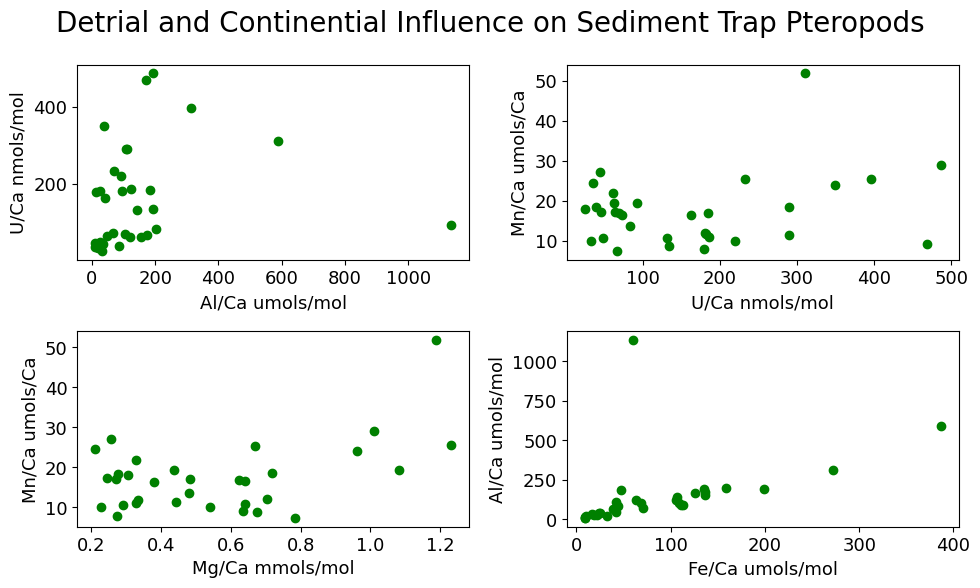

In [23]:
#graph 14: create subplots w linear regression lines for U/Ca vs Mg/Ca , Al/Ca vs U/Ca, U/Ca vs Mn/Ca, Mg/Ca vs Mn/Ca, Fe/Ca vs Al/ca
fig, (axes) = plt.subplots(nrows=2, ncols=2, figsize=(10,6))


axes[0,0].scatter(Al_Ca2, U_Ca2, color = 'green')
axes[0,0].set_xlabel('Al/Ca umols/mol')
axes[0,0].set_ylabel('U/Ca nmols/mol')

axes[0,1].scatter(U_Ca2, Mn_Ca2, color = 'green')
axes[0,1].set_xlabel('U/Ca nmols/mol')
axes[0,1].set_ylabel('Mn/Ca umols/Ca')

axes[1,0].scatter(Mg_Ca2, Mn_Ca2, color = 'green')
axes[1,0].set_xlabel('Mg/Ca mmols/mol')
axes[1,0].set_ylabel('Mn/Ca umols/Ca')

axes[1,1].scatter(Fe_Ca2, Al_Ca2, color = 'green')
axes[1,1].set_xlabel('Fe/Ca umols/mol')
axes[1,1].set_ylabel('Al/Ca umols/mol')

fig.suptitle('Detrial and Continential Influence on Sediment Trap Pteropods', fontsize = 20)


#fig.legend(bbox_to_anchor=(1.02, 0.5), loc='center left', borderaxespad=0)

# Adjusting layout for better spacing
fig.tight_layout()


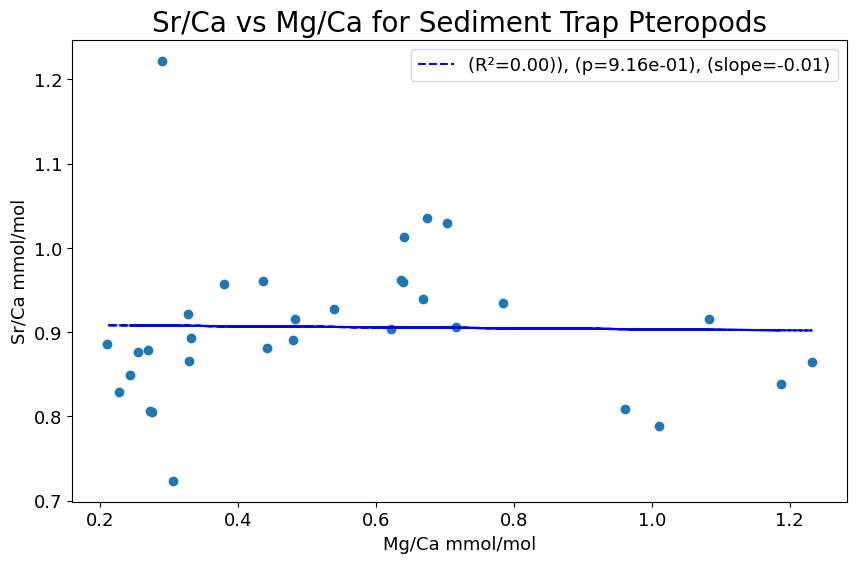

In [24]:
#water column sr/ca vs mg/ca 

plt.figure(figsize=(10,6))

plt.scatter(Mg_Ca2, Sr_Ca2)

# calulate linear regression
slopeSrMg, interceptSrMg, r_valueSrMg, p_valueSrMg, std_errSrMg = linregress(Mg_Ca2, Sr_Ca2)
regression_ySrMg = slopeSrMg * Mg_Ca2 + interceptSrMg
r_squaredSrMg = r_valueSrMg**2

#plot linear regression
plt.plot(Mg_Ca2, regression_ySrMg, label=f'(R²={r_squaredSrMg:.2f})), (p={p_valueSrMg:.2e}), (slope={slopeSrMg:.2f})', color='b', linestyle='--')


plt.xlabel('Mg/Ca mmol/mol')
plt.ylabel('Sr/Ca mmol/mol')
plt.title('Sr/Ca vs Mg/Ca for Sediment Trap Pteropods', fontsize = 20)
plt.legend()


Text(0.5, 1.0, 'Time Series of Ba/Ca Ratio Variation in Water Column Pteropods')

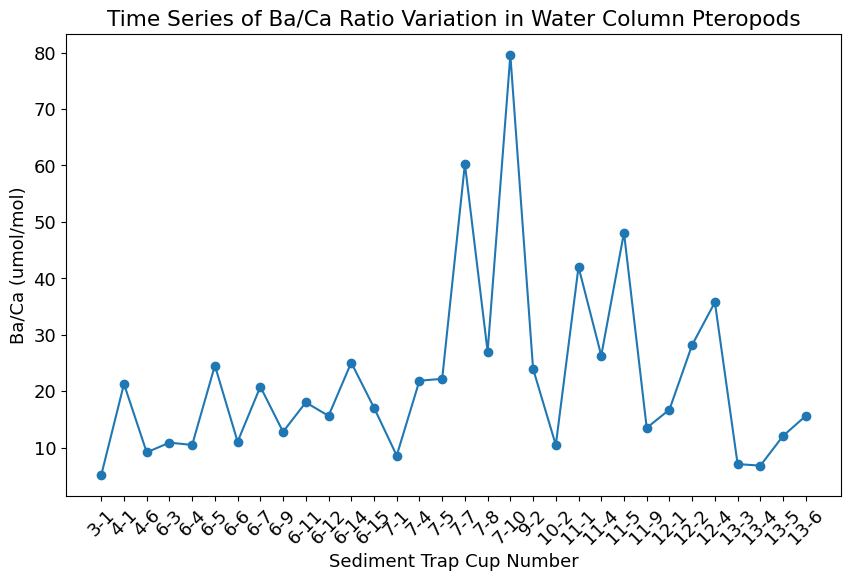

In [25]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

plt.figure(figsize=(10,6))

plt.scatter(cup2, Ba_Ca2)
plt.plot(cup2, Ba_Ca2)
plt.xlabel('Sediment Trap Cup Number')
plt.xticks(rotation = 45)
plt.ylabel('Ba/Ca (umol/mol)')
plt.title('Time Series of Ba/Ca Ratio Variation in Water Column Pteropods')

Text(0.5, 1.0, 'Time Series of Sr/Ca Ratio Variation in Water Column Pteropods')

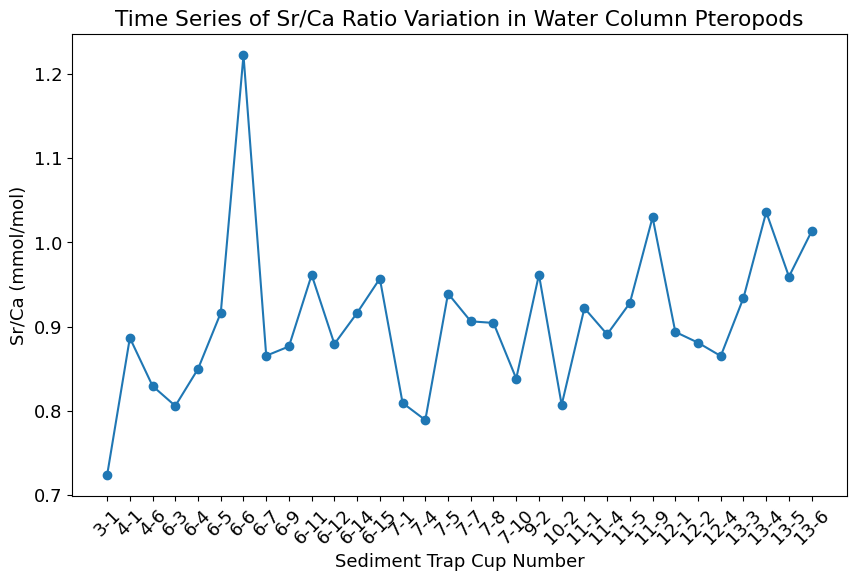

In [26]:
#water column cup # analysis

plt.figure(figsize=(10,6))

plt.scatter(cup2, Sr_Ca2)
plt.plot(cup2, Sr_Ca2)
plt.xlabel('Sediment Trap Cup Number')
plt.xticks(rotation = 45)
plt.ylabel('Sr/Ca (mmol/mol)')
plt.title('Time Series of Sr/Ca Ratio Variation in Water Column Pteropods')

Text(0.5, 1.0, 'Time Series of U/Ca Ratio Variation in Water Column Pteropods')

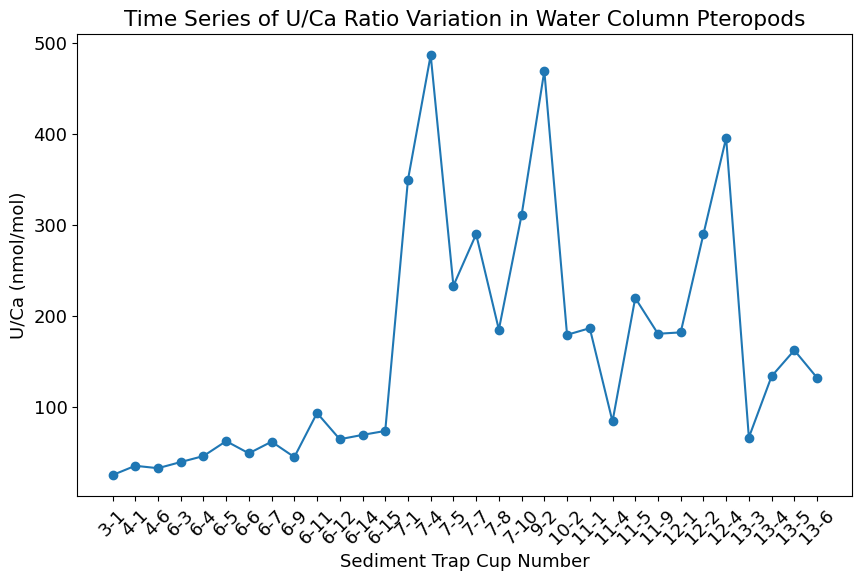

In [27]:
#water column cup # analysis

plt.figure(figsize=(10,6))

plt.scatter(cup2, U_Ca2)
plt.plot(cup2, U_Ca2)
plt.xlabel('Sediment Trap Cup Number')
plt.xticks(rotation = 45)
plt.ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of U/Ca Ratio Variation in Water Column Pteropods')

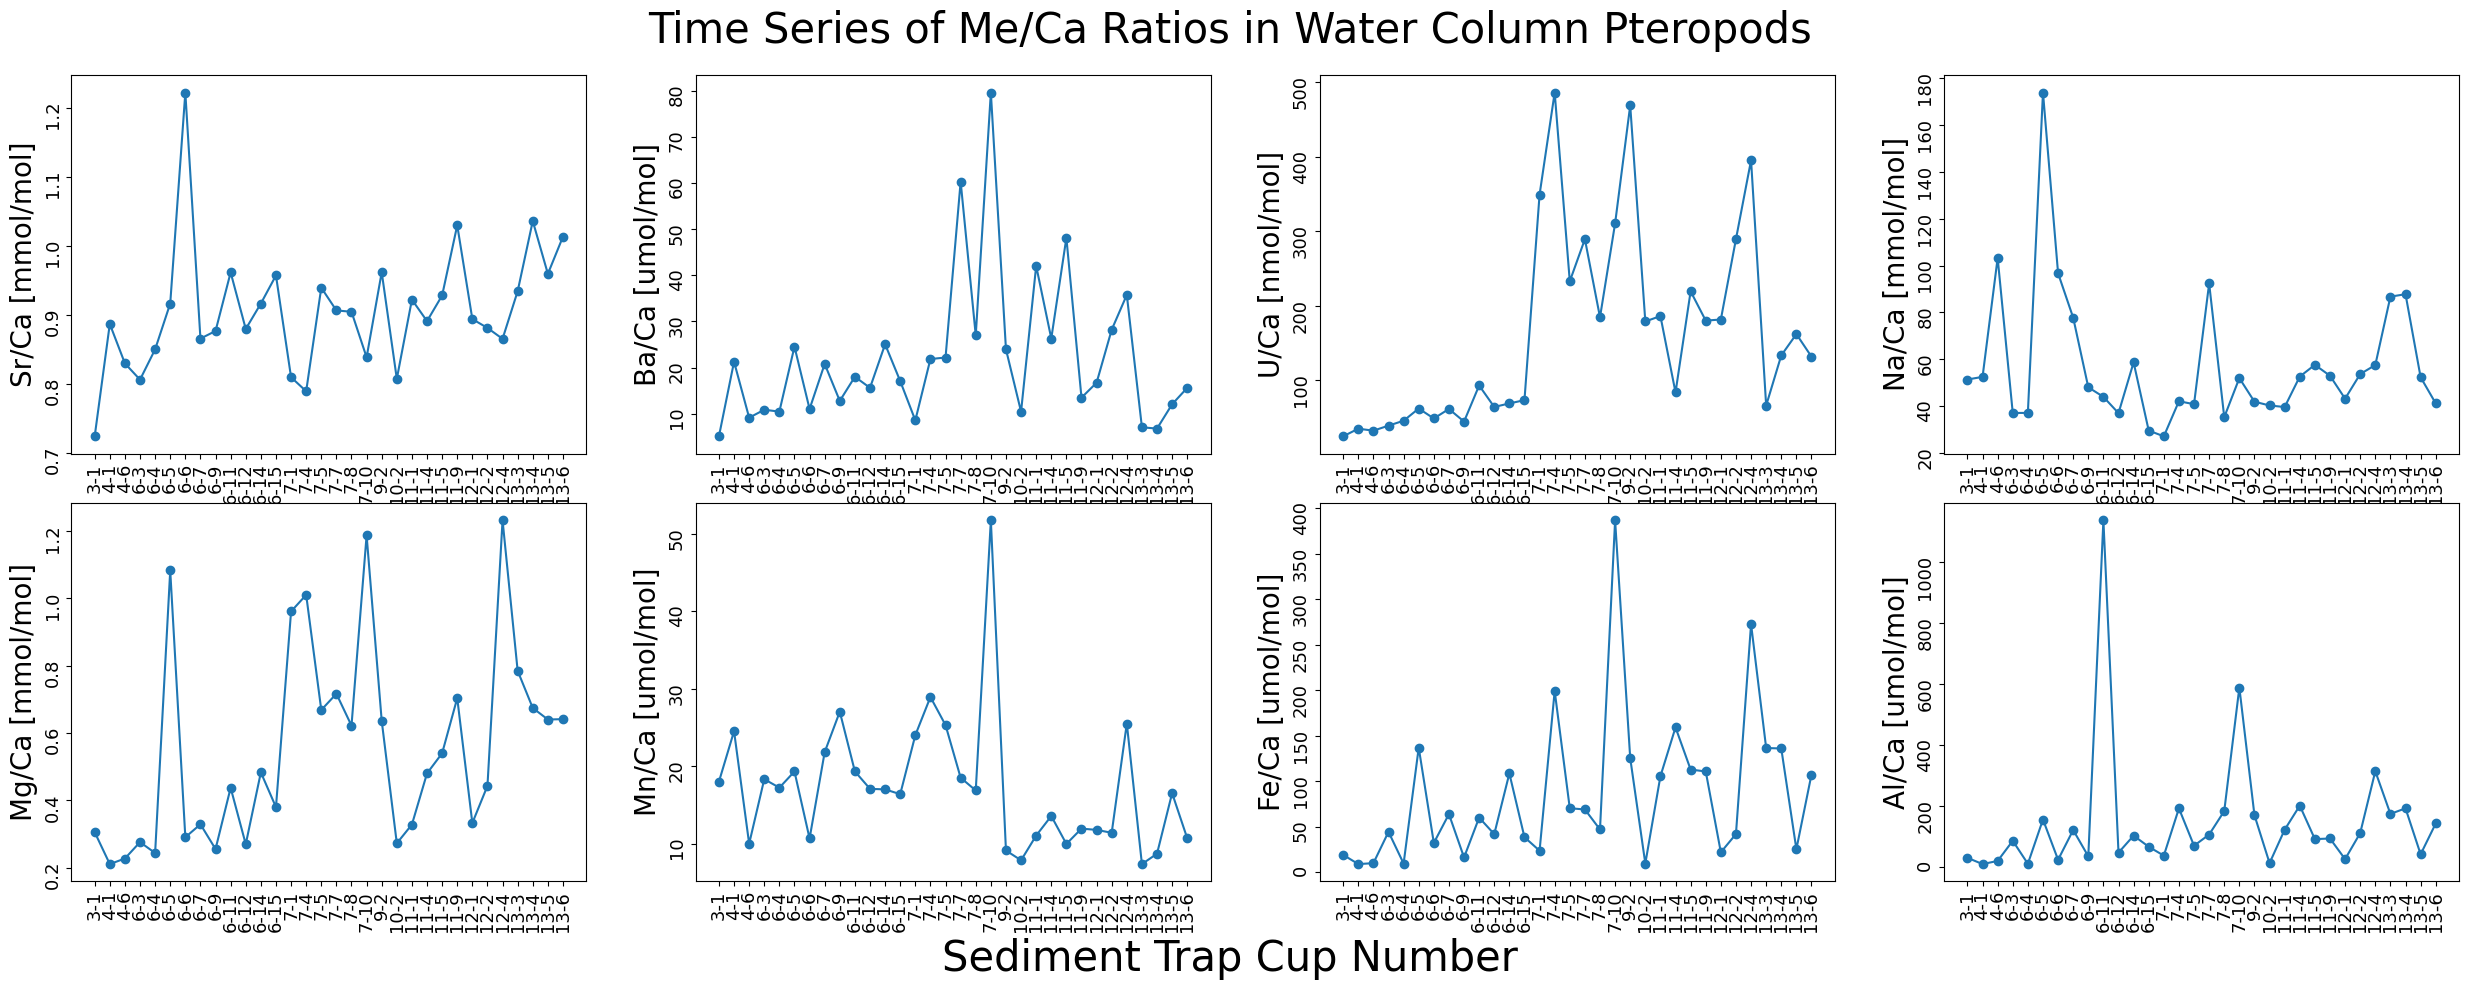

In [28]:
#graph 13: Me/Ca vs LDX


#create figure
fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=False, sharey=False)
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8 = axes.flatten()


#create scatter plots

ax1.scatter(cup2, Sr_Ca2)

ax2.scatter(cup2, Ba_Ca2)

ax3.scatter(cup2, U_Ca2)

ax4.scatter(cup2, Na_Ca2)

ax5.scatter(cup2, Mg_Ca2)

ax6.scatter(cup2, Mn_Ca2)

ax7.scatter(cup2, Fe_Ca2) 

ax8.scatter(cup2, Al_Ca2)

#plot linear regression 

ax1.plot(cup2, Sr_Ca2)

ax2.plot(cup2, Ba_Ca2)

ax3.plot(cup2, U_Ca2)

ax4.plot(cup2, Na_Ca2)

ax5.plot(cup2, Mg_Ca2)

ax6.plot(cup2, Mn_Ca2)

ax7.plot(cup2, Fe_Ca2) 

ax8.plot(cup2, Al_Ca2)

#label axes
ax1.set_ylabel('Sr/Ca [mmol/mol]', fontsize=20)
ax1.set_xlabel('')

ax2.set_ylabel('Ba/Ca [umol/mol]', fontsize=20)
ax2.set_xlabel('')

ax3.set_ylabel('U/Ca [nmol/mol]', fontsize=20)
ax3.set_xlabel('')

ax4.set_ylabel('Na/Ca [mmol/mol]', fontsize=20)
ax4.set_xlabel('')

ax5.set_ylabel('Mg/Ca [mmol/mol]', fontsize=20)
ax5.set_xlabel('')

ax6.set_ylabel('Mn/Ca [umol/mol]', fontsize=20)
ax6.set_xlabel('')

ax7.set_ylabel('Fe/Ca [umol/mol]', fontsize=20)
ax7.set_xlabel('')

ax8.set_ylabel('Al/Ca [umol/mol]', fontsize=20)
ax8.set_xlabel('')




#plot title
fig.suptitle('Time Series of Me/Ca Ratios in Water Column Pteropods', fontsize = 30)
fig.supxlabel('Sediment Trap Cup Number', fontsize= 30)
# fig.supylabel('Me/Ca Ratios', fontsize= 30)

#fixing spacing layout
fig.tight_layout()

#legends
ax1.tick_params(labelrotation=90)
ax2.tick_params(labelrotation=90)
ax3.tick_params(labelrotation=90)
ax4.tick_params(labelrotation=90)
ax5.tick_params(labelrotation=90)
ax6.tick_params(labelrotation=90)
ax7.tick_params(labelrotation=90)
ax8.tick_params(labelrotation=90)


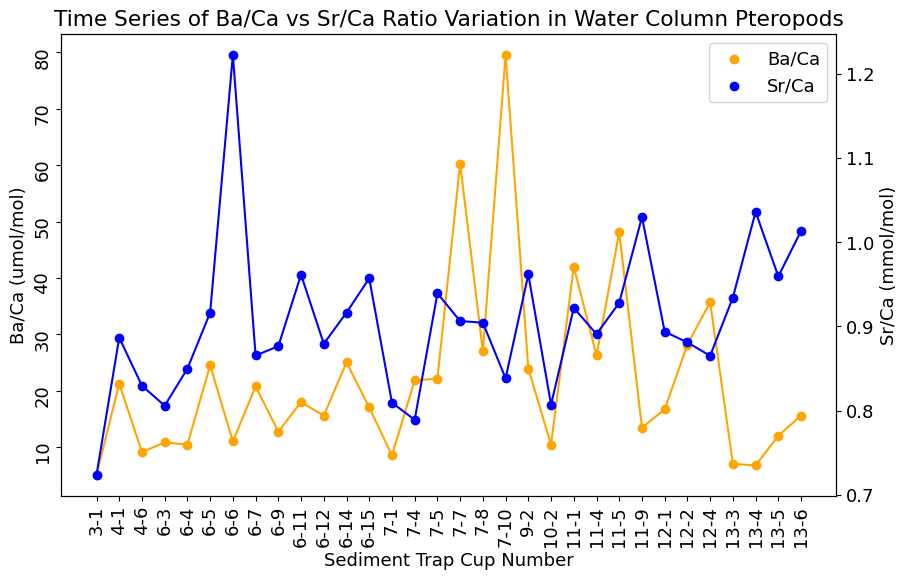

In [29]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Ba_Ca2, color= 'orange', label= 'Ba/Ca')
ax1.plot(cup2, Ba_Ca2, color= 'orange')
ax2.scatter(cup2, Sr_Ca2, color='b', label = 'Sr/Ca')
ax2.plot(cup2, Sr_Ca2, color='b')

plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Ba/Ca (umol/mol)')
ax2.set_ylabel('Sr/Ca (mmol/mol)')
plt.title('Time Series of Ba/Ca vs Sr/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')
#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

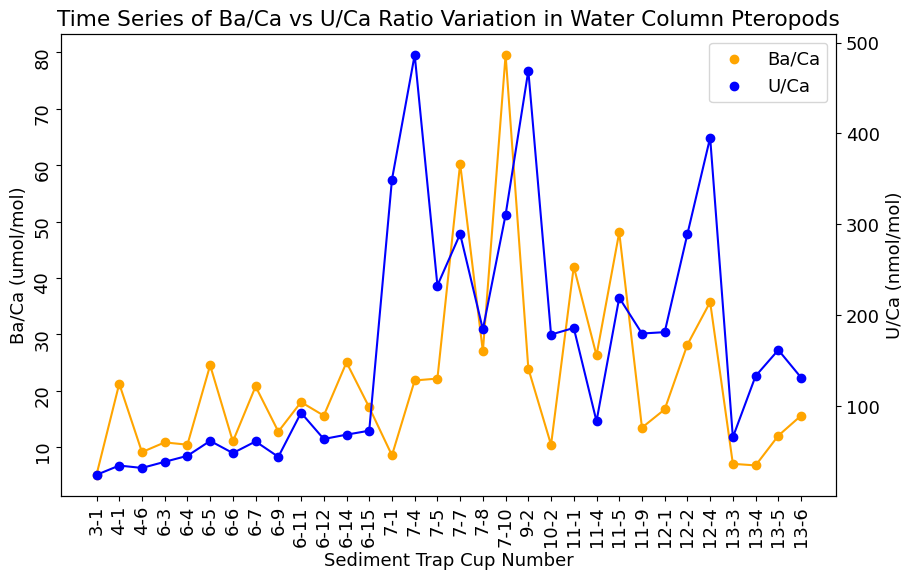

In [30]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Ba_Ca2, color= 'orange', label= 'Ba/Ca')
ax1.plot(cup2, Ba_Ca2, color= 'orange')
ax2.scatter(cup2, U_Ca2, color='b', label = 'U/Ca')
ax2.plot(cup2, U_Ca2, color='b')

label1= ('Ba/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Ba/Ca (umol/mol)')
ax2.set_ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of Ba/Ca vs U/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')

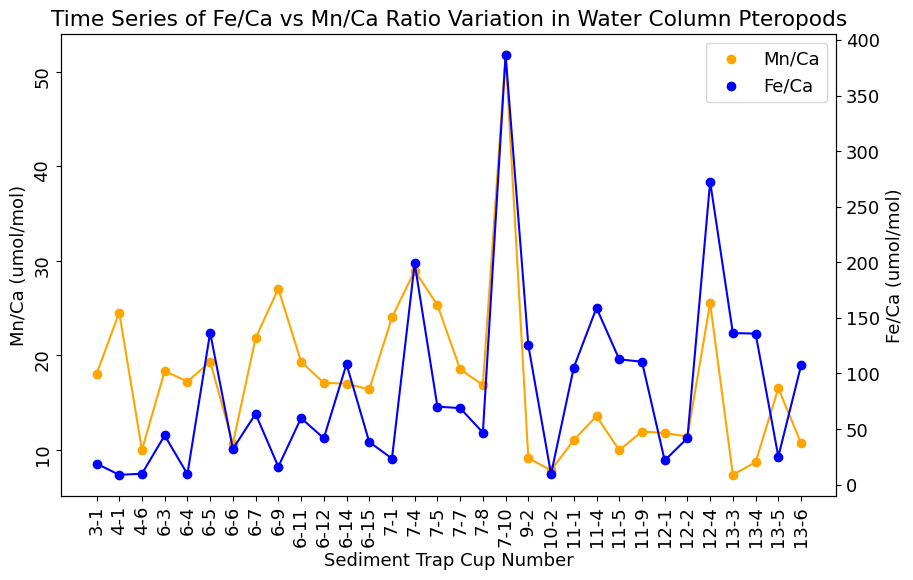

In [31]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Mn_Ca2, color= 'orange', label= 'Mn/Ca')
ax1.plot(cup2, Mn_Ca2, color= 'orange')
ax2.scatter(cup2, Fe_Ca2, color='b', label = 'Fe/Ca')
ax2.plot(cup2, Fe_Ca2, color='b')

label1= ('Mn/Ca') 
label2 = ('Fe/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Mn/Ca (umol/mol)')
ax2.set_ylabel('Fe/Ca (umol/mol)')
plt.title('Time Series of Fe/Ca vs Mn/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


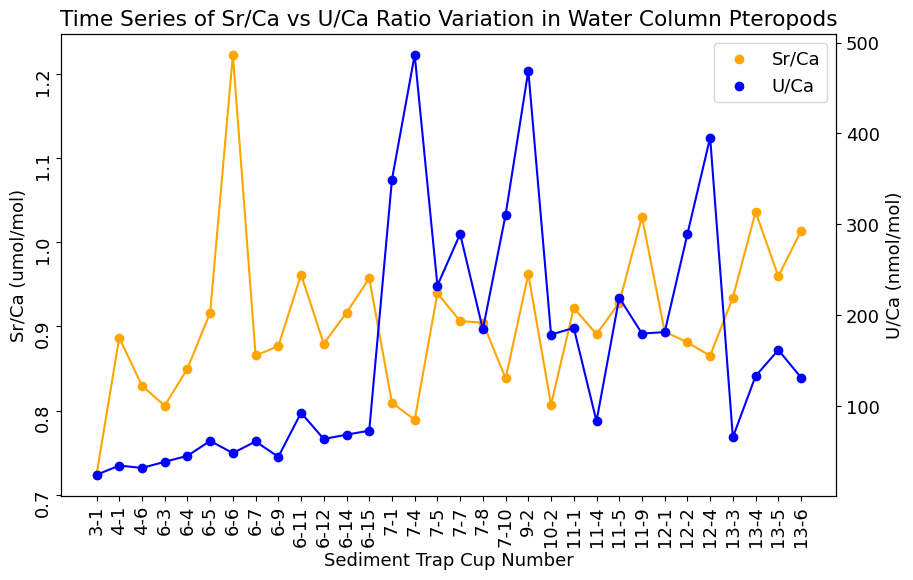

In [32]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Sr_Ca2, color= 'orange', label= 'Sr/Ca')
ax1.plot(cup2, Sr_Ca2, color= 'orange')
ax2.scatter(cup2, U_Ca2, color='b', label = 'U/Ca')
ax2.plot(cup2, U_Ca2, color='b')

label1= ('Sr/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Sr/Ca (umol/mol)')
ax2.set_ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of Sr/Ca vs U/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


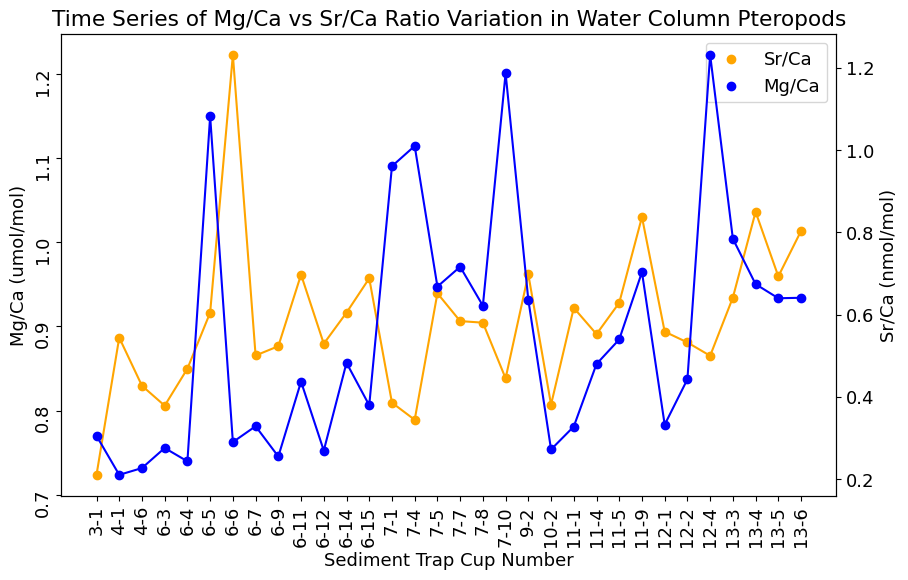

In [33]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Sr_Ca2, color= 'orange', label= 'Sr/Ca')
ax1.plot(cup2, Sr_Ca2, color= 'orange')
ax2.scatter(cup2, Mg_Ca2, color='b', label = 'Mg/Ca')
ax2.plot(cup2, Mg_Ca2, color='b')

label1= ('Ba/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Mg/Ca (umol/mol)')
ax2.set_ylabel('Sr/Ca (nmol/mol)')
plt.title('Time Series of Mg/Ca vs Sr/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


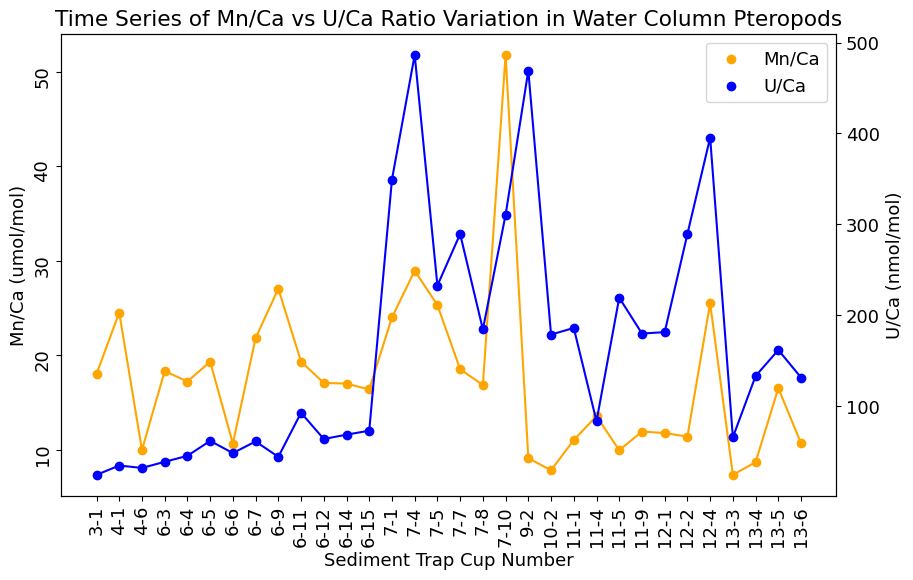

In [34]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Mn_Ca2, color= 'orange', label= 'Mn/Ca')
ax1.plot(cup2, Mn_Ca2, color= 'orange')
ax2.scatter(cup2, U_Ca2, color='b', label = 'U/Ca')
ax2.plot(cup2, U_Ca2, color='b')

label1= ('Mn/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Mn/Ca (umol/mol)')
ax2.set_ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of Mn/Ca vs U/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


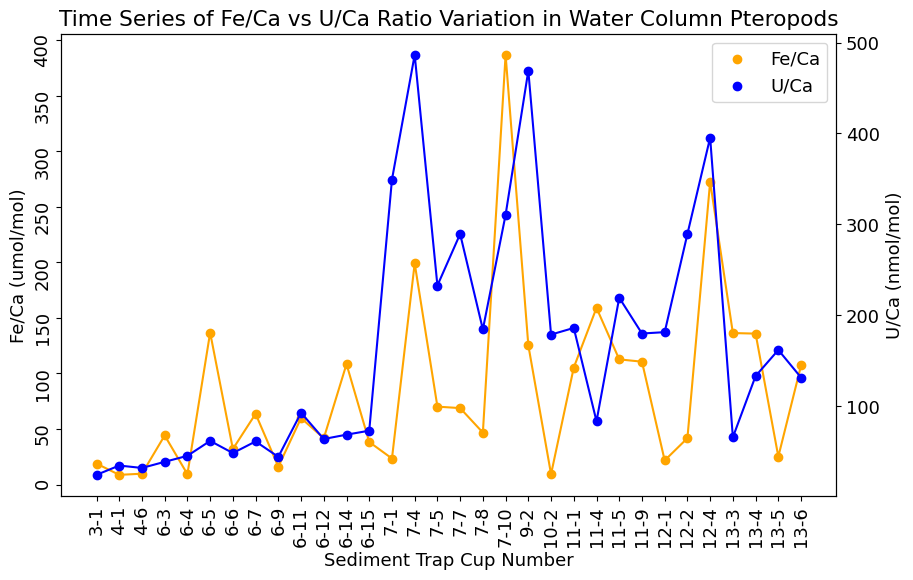

In [35]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Fe_Ca2, color= 'orange', label= 'Fe/Ca')
ax1.plot(cup2, Fe_Ca2, color= 'orange')
ax2.scatter(cup2, U_Ca2, color='b', label = 'U/Ca')
ax2.plot(cup2, U_Ca2, color='b')

label1= ('Fe/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Fe/Ca (umol/mol)')
ax2.set_ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of Fe/Ca vs U/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


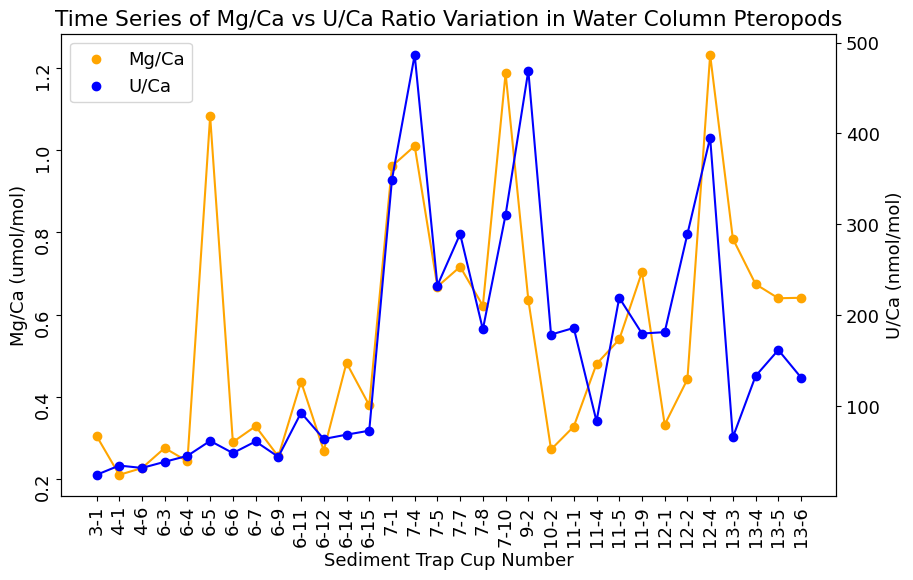

In [36]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Mg_Ca2, color= 'orange', label= 'Mg/Ca')
ax1.plot(cup2, Mg_Ca2, color= 'orange')
ax2.scatter(cup2, U_Ca2, color='b', label = 'U/Ca')
ax2.plot(cup2, U_Ca2, color='b')

label1= ('Mg/Ca') 
label2 = ('U/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Mg/Ca (umol/mol)')
ax2.set_ylabel('U/Ca (nmol/mol)')
plt.title('Time Series of Mg/Ca vs U/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')


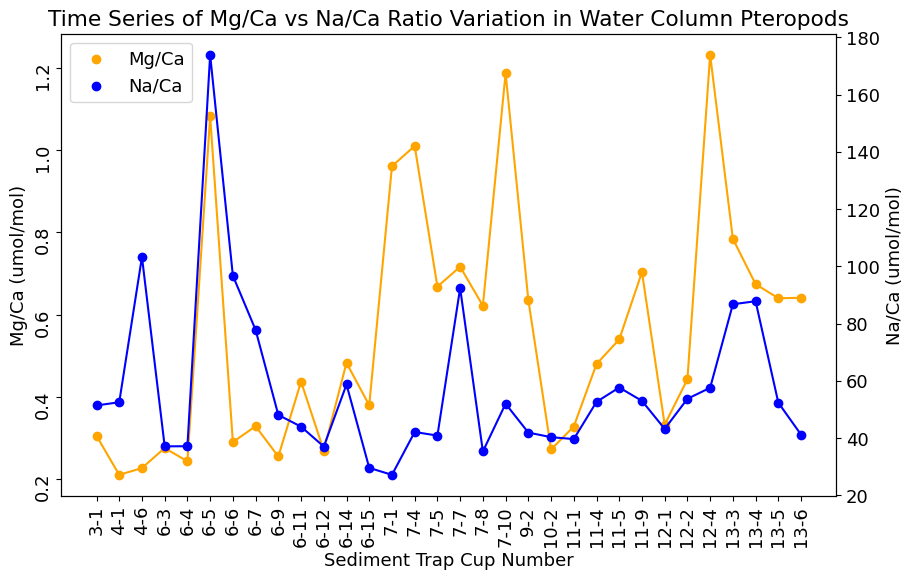

In [37]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Mg_Ca2, color= 'orange', label= 'Mg/Ca')
ax1.plot(cup2, Mg_Ca2, color= 'orange')
ax2.scatter(cup2, Na_Ca2, color='b', label = 'Na/Ca')
ax2.plot(cup2, Na_Ca2, color='b')

label1= ('Mg/Ca') 
label2 = ('Na/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Mg/Ca (umol/mol)')
ax2.set_ylabel('Na/Ca (umol/mol)')
plt.title('Time Series of Mg/Ca vs Na/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')


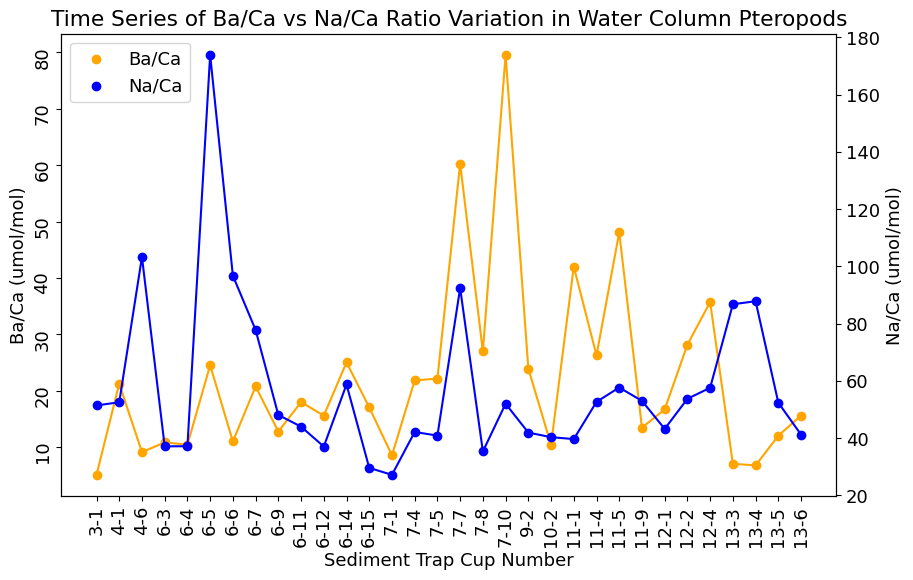

In [38]:
#water column cup # analysis

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Ba_Ca2, color= 'orange', label= 'Ba/Ca')
ax1.plot(cup2, Ba_Ca2, color= 'orange')
ax2.scatter(cup2, Na_Ca2, color='b', label = 'Na/Ca')
ax2.plot(cup2, Na_Ca2, color='b')

label1= ('Ba/Ca') 
label2 = ('Na/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Ba/Ca (umol/mol)')
ax2.set_ylabel('Na/Ca (umol/mol)')
plt.title('Time Series of Ba/Ca vs Na/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')


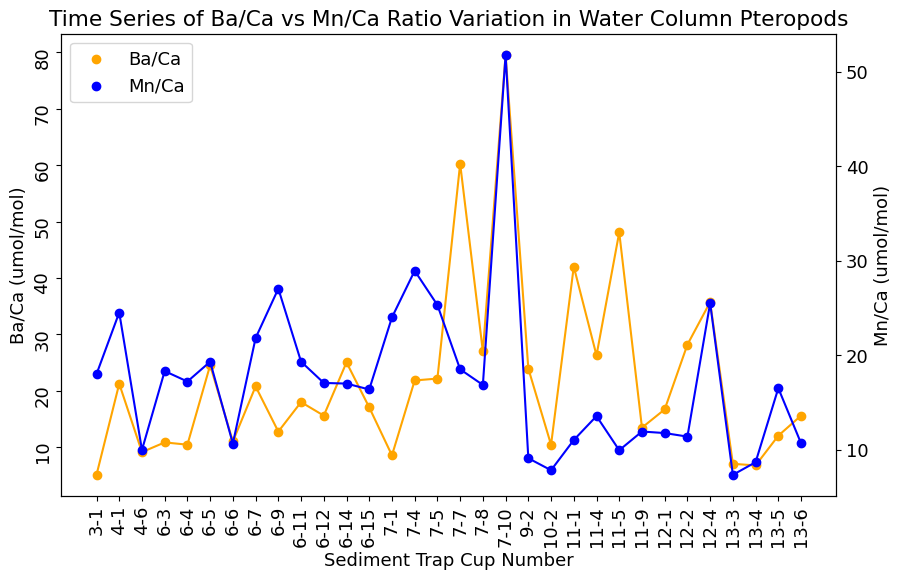

In [78]:
#water column cup # analysis

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Ba_Ca2, color= 'orange', label= 'Ba/Ca')
ax1.plot(cup2, Ba_Ca2, color= 'orange')
ax2.scatter(cup2, Mn_Ca2, color='b', label = 'Mn/Ca')
ax2.plot(cup2, Mn_Ca2, color='b')

label1= ('Ba/Ca') 
label2 = ('Mn/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Ba/Ca (umol/mol)')
ax2.set_ylabel('Mn/Ca (umol/mol)')
plt.title('Time Series of Ba/Ca vs Mn/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')


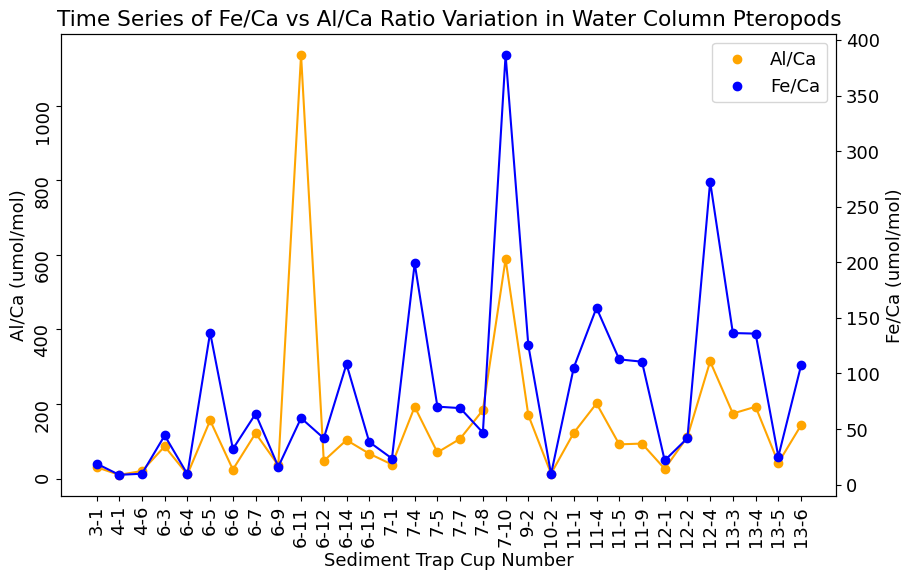

In [80]:
#water column cup # analysis

# print(wpterodatanonan.columns)

cup = wpterodatanonan['cup']
cup2 = wpterodatanonan['Label']

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Al_Ca2, color= 'orange', label= 'Al/Ca')
ax1.plot(cup2, Al_Ca2, color= 'orange')
ax2.scatter(cup2, Fe_Ca2, color='b', label = 'Fe/Ca')
ax2.plot(cup2, Fe_Ca2, color='b')

label1= ('Al/Ca') 
label2 = ('Fe/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Al/Ca (umol/mol)')
ax2.set_ylabel('Fe/Ca (umol/mol)')
plt.title('Time Series of Fe/Ca vs Al/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')

#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper right')


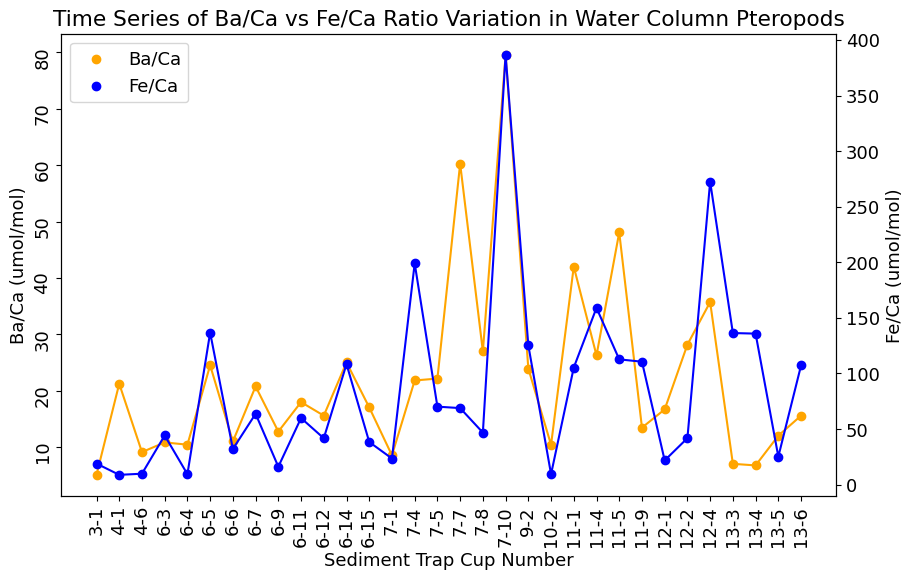

In [82]:
#water column cup # analysis

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Ba_Ca2, color= 'orange', label= 'Ba/Ca')
ax1.plot(cup2, Ba_Ca2, color= 'orange')
ax2.scatter(cup2, Fe_Ca2, color='b', label = 'Fe/Ca')
ax2.plot(cup2, Fe_Ca2, color='b')

label1= ('Ba/Ca') 
label2 = ('Fe/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Ba/Ca (umol/mol)')
ax2.set_ylabel('Fe/Ca (umol/mol)')
plt.title('Time Series of Ba/Ca vs Fe/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')


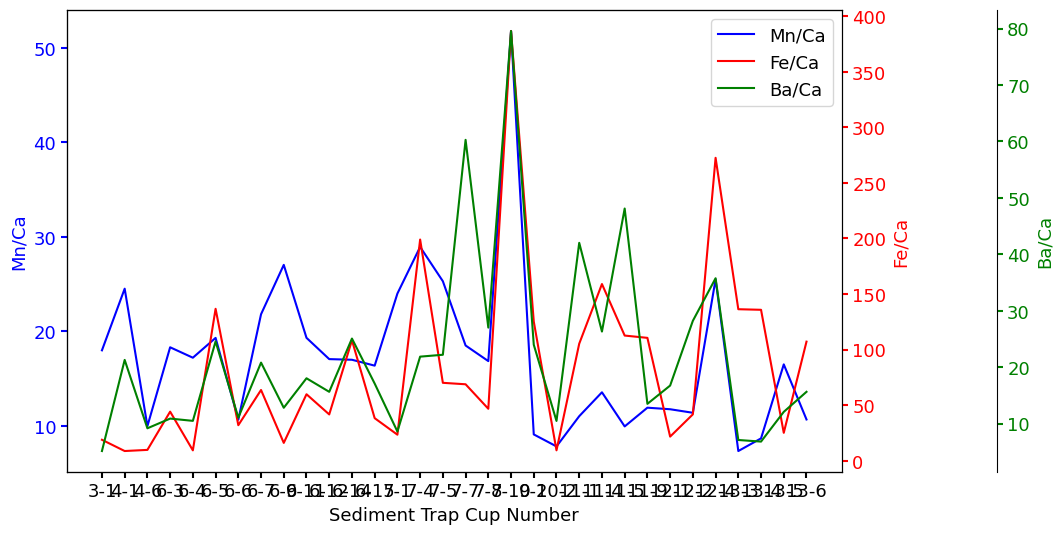

In [90]:

fig, ax = plt.subplots(figsize = (10,6))


twin1 = ax.twinx()
twin2 = ax.twinx()

# Offset the right spine of twin2.  The ticks and label have already been
# placed on the right by twinx above.
twin2.spines.right.set_position(("axes", 1.2))

p1, = ax.plot(cup2, Mn_Ca2, "b-", label="Mn/Ca")
p2, = twin1.plot(cup2, Fe_Ca2, "r-", label="Fe/Ca")
p3, = twin2.plot(cup2, Ba_Ca2, "g-", label="Ba/Ca")


ax.set_xlabel("Sediment Trap Cup Number")
ax.set_ylabel("Mn/Ca")
twin1.set_ylabel("Fe/Ca")
twin2.set_ylabel("Ba/Ca")

ax.yaxis.label.set_color(p1.get_color())
twin1.yaxis.label.set_color(p2.get_color())
twin2.yaxis.label.set_color(p3.get_color())

tkw = dict(size=4, width=1.5)
ax.tick_params(axis='y', colors=p1.get_color(), **tkw)
twin1.tick_params(axis='y', colors=p2.get_color(), **tkw)
twin2.tick_params(axis='y', colors=p3.get_color(), **tkw)
ax.tick_params(axis='x', **tkw)

ax.legend(handles=[p1, p2, p3])

plt.show()

In [ ]:
#water column cup # analysis

fig, ax1= plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()

ax1.scatter(cup2, Na_Ca2, color= 'orange', label= 'Na/Ca')
ax1.plot(cup2, Na_Ca2, color= 'orange')
ax2.scatter(cup2, Al_Ca2, color='b', label = 'Al/Ca')
ax2.plot(cup2, Al_Ca2, color='b')

label1= ('Na/Ca') 
label2 = ('Al/Ca')
plt.xlabel('Sediment Trap Cup Number')
ax1.tick_params(labelrotation=90)
ax1.set_ylabel('Na/Ca (umol/mol)')
ax2.set_ylabel('Al/Ca (umol/mol)')
plt.title('Time Series of Ba/Ca vs Fe/Ca Ratio Variation in Water Column Pteropods')
ax1.set_xlabel('Sediment Trap Cup Number')


#add legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')
